In [1]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from datetime import datetime, timedelta
import os

# Database configuration
DB_CONFIG = {
    'host': '10.205.161.118',
    'port': '5432',
    'database': 'db_fraud',
    'user': 'dfstechbi',
    'password': 'DfsTeChB1@923'
}

# JDBC Configuration
jdbc_driver_path = "/root/research-dir/dev/jazzcash-fraud-detection/utils/postgresql-42.7.1.jar"
jdbc_url = f"jdbc:postgresql://{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"

# Optimized JDBC properties
properties = {
    "user": DB_CONFIG['user'],
    "password": DB_CONFIG['password'],
    "driver": "org.postgresql.Driver",
    "fetchsize": "10000",
    "batchsize": "15000",
    "isolationLevel": "READ_UNCOMMITTED",
    "queryTimeout": "1200",
    "loginTimeout": "60",
    "socketTimeout": "1200",
    "tcpKeepAlive": "true",
    "prepareThreshold": "5",
    "reWriteBatchedInserts": "true",
    "defaultRowFetchSize": "10000"
}

print("🚀 Creating optimized Spark session for asymmetric cluster...")
print("📊 Cluster Resources:")
print("   • Worker 1: 32 cores, 120GB RAM")
print("   • Worker 2: 32 cores, 110GB RAM")
print("   • Total: 64 cores, 230GB RAM")

# Create Spark session with optimized configuration for asymmetric cluster
spark = SparkSession.builder \
    .appName("Feature-Job-Optimized") \
    .master("spark://dfs-ai-app2:7077") \
    .config("spark.jars", jdbc_driver_path) \
    .config("spark.executor.instances", "12") \
    .config("spark.executor.cores", "5") \
    .config("spark.executor.memory", "17g") \
    .config("spark.executor.memoryOverhead", "3g") \
    .config("spark.driver.memory", "4g") \
    .config("spark.driver.memoryOverhead", "1g") \
    .config("spark.driver.cores", "2") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.sql.adaptive.advisoryPartitionSizeInBytes", "128MB") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.shuffle.service.enabled", "false") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.default.parallelism", "120") \
    .config("spark.sql.autoBroadcastJoinThreshold", "100MB") \
    .config("spark.executor.extraJavaOptions", "-Xss4m") \
    .config("spark.driver.extraJavaOptions", "-Xss4m") \
    .getOrCreate()



# Set log level to reduce noise
spark.sparkContext.setLogLevel("WARN")

print("✅ Spark session created successfully!")
print(f"📱 Application ID: {spark.sparkContext.applicationId}")
print(f"🎯 Master: {spark.sparkContext.master}")
print(f"🔧 Configuration Summary:")
print(f"   • Executors: 12 instances")
print(f"   • Cores per executor: 5")
print(f"   • Memory per executor: 17GB + 3GB overhead")
print(f"   • Driver: 4GB + 1GB overhead, 2 cores")
print(f"   • Total executor cores: 60 (leaving 4 for OS)")
print(f"   • Total executor memory: ~204GB (leaving ~26GB for OS/overhead)")

🚀 Creating optimized Spark session for asymmetric cluster...
📊 Cluster Resources:
   • Worker 1: 32 cores, 120GB RAM
   • Worker 2: 32 cores, 110GB RAM
   • Total: 64 cores, 230GB RAM


25/10/23 14:17:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/23 14:17:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


✅ Spark session created successfully!
📱 Application ID: app-20251023141712-0043
🎯 Master: spark://dfs-ai-app2:7077
🔧 Configuration Summary:
   • Executors: 12 instances
   • Cores per executor: 5
   • Memory per executor: 17GB + 3GB overhead
   • Driver: 4GB + 1GB overhead, 2 cores
   • Total executor cores: 60 (leaving 4 for OS)
   • Total executor memory: ~204GB (leaving ~26GB for OS/overhead)


## Load ClickHouse Feature Data into Spark
Load the user-level features from ClickHouse into Spark DataFrame for further analysis

In [ ]:
# ClickHouse JDBC Configuration
clickhouse_jdbc_url = "jdbc:clickhouse://10.205.161.118:8123/public"

# ClickHouse JDBC properties
clickhouse_properties = {
    "user": "default",
    "password": "DfsTeChB1",
    "driver": "com.clickhouse.jdbc.ClickHouseDriver",
    "socket_timeout": "300000",
    "connection_timeout": "30000"
}

print("🔗 Loading feature data from ClickHouse...")
print(f"📊 Source: ac_from_features_distributed")
print(f"🌐 ClickHouse: 10.205.161.118:8123")

# Query to load all features
feature_query = """
(SELECT 
    ac_from,
    cutoff_date,
    total_txns_1d,
    total_amount_1d,
    avg_amount_1d,
    median_amount_1d,
    max_amount_1d,
    min_amount_1d,
    unique_recipients_1d,
    unique_channels_1d,
    unique_types_1d,
    total_txns_3d,
    total_amount_3d,
    avg_amount_3d,
    median_amount_3d,
    max_amount_3d,
    min_amount_3d,
    unique_recipients_3d,
    unique_channels_3d,
    unique_types_3d,
    total_txns_7d,
    total_amount_7d,
    avg_amount_7d,
    median_amount_7d,
    max_amount_7d,
    min_amount_7d,
    unique_recipients_7d,
    unique_channels_7d,
    unique_types_7d,
    most_used_channel_7d,
    last_used_channel,
    channel_diversity_score_7d,
    most_used_type_7d,
    last_used_type,
    type_diversity_score_7d,
    night_txns_7d,
    weekend_txns_7d,
    peak_hour_txns_7d,
    off_peak_hour_txns_7d,
    avg_start_balance_7d,
    avg_end_balance_7d,
    min_balance_7d,
    max_balance_7d,
    balance_volatility_7d,
    top_recipient_7d,
    avg_amount_per_recipient_7d,
    max_amount_to_single_recipient_7d,
    recipient_concentration_ratio_7d,
    avg_time_between_txns_7d,
    txn_frequency_score_7d,
    first_txn_time,
    last_txn_time,
    days_since_first_txn,
    days_since_last_txn,
    processing_timestamp,
    created_at
FROM public.ac_from_features_distributed) as features
"""

# Load data from ClickHouse
df_features = spark.read \
    .jdbc(url=clickhouse_jdbc_url, table=feature_query, properties=clickhouse_properties)

print(f"✅ Feature data loaded successfully!")
print(f"📊 Total records: {df_features.count():,}")
print(f"📋 Total columns: {len(df_features.columns)}")
print(f"\n🔧 Schema:")
df_features.printSchema()

In [ ]:
# Display sample data
print("\n" + "="*80)
print("📊 Sample Feature Data")
print("="*80)

df_features.show(10, truncate=False)

print("\n" + "="*80)
print("📈 Summary Statistics")
print("="*80)

# Select numeric columns for statistics
numeric_cols = [
    'total_txns_1d', 'total_txns_3d', 'total_txns_7d',
    'total_amount_1d', 'total_amount_3d', 'total_amount_7d',
    'avg_amount_1d', 'avg_amount_3d', 'avg_amount_7d',
    'unique_recipients_7d', 'unique_channels_7d', 'unique_types_7d'
]

df_features.select(numeric_cols).describe().show()

print("\n" + "="*80)
print("🔍 Feature Distribution Overview")
print("="*80)

# Show counts and nulls for key features
for col in numeric_cols:
    null_count = df_features.filter(F.col(col).isNull()).count()
    zero_count = df_features.filter(F.col(col) == 0).count()
    print(f"{col:30s}: nulls={null_count:>6,}, zeros={zero_count:>6,}")

In [ ]:
# Cache the DataFrame for faster access
df_features.cache()

print("💾 DataFrame cached in memory")
print(f"📊 Partitions: {df_features.rdd.getNumPartitions()}")
print(f"📈 Total records: {df_features.count():,}")

# Register as temp view for SQL queries
df_features.createOrReplaceTempView("user_features")

print("✅ Temporary view 'user_features' created")
print("\n💡 You can now query using:")
print("   spark.sql('SELECT * FROM user_features WHERE total_txns_7d > 10')")

In [2]:
# Create predicates for optimized partitioning
predicates = []
start_date = datetime.strptime("2025-07-01", "%Y-%m-%d")
end_date = datetime.strptime("2025-07-31", "%Y-%m-%d")

current_date = start_date
while current_date <= end_date:
    date_str = current_date.strftime("%Y-%m-%d")
    predicates.append(f"data_date = '{date_str}'")
    current_date += timedelta(days=1)

print("\n🔗 Loading data from PostgreSQL...")

# Create query to select only specified columns
query = """
SELECT data_date, ac_from, trans_id, trans_initiate_time, trx_channel, trx_type, start_balance
FROM public.stixor_iar_jul
"""

# Load data using predicate-based partitioning with column selection
df = spark.read.jdbc(
    url=jdbc_url,
    table=f"({query}) as filtered_data",
    properties=properties,
    predicates=predicates
)


🔗 Loading data from PostgreSQL...


In [3]:
df.count()

412154243

In [4]:
# channel_counts = df.groupBy("trx_channel").count().collect()
# type_counts = df.groupBy("trx_type").count().collect()

# print("\n📊 Transaction Channel Distribution:")
# for row in channel_counts:
#     print(f"   • {row['trx_channel']}: {row['count']:,}")

# print("\n📊 Transaction Type Distribution:")
# for row in type_counts:
#     print(f"   • {row['trx_type']}: {row['count']:,}")

# # Create stratified sample maintaining proportions
# # Sample 10% from each channel-type combination, then limit to 1M
# sample_df = df.sampleBy("trx_channel", fractions={row['trx_channel']: 0.1 for row in channel_counts}, seed=42)

# # If we need exactly 1M records, we can further sample
# total_sampled = sample_df.count()
# if total_sampled > 1000000:
#     # Calculate fraction needed to get close to 1M
#     fraction = min(1.0, 1000000 / total_sampled)
#     sample_df = sample_df.sample(fraction=fraction, seed=42)

# print(f"\n📊 Stratified sample created: {sample_df.count():,} transactions")

In [5]:
# Take a sample of 1 million transactions from df
sample_df = df.sample(fraction=0.1, seed=42).limit(1000000)
print(f"📊 Sampled {sample_df.count():,} transactions")

📊 Sampled 1,000,000 transactions


In [6]:
sample_df.show()

+----------+--------------------+-----------+-------------------+---------------+--------------------+--------------------+
| data_date|             ac_from|   trans_id|trans_initiate_time|    trx_channel|            trx_type|       start_balance|
+----------+--------------------+-----------+-------------------+---------------+--------------------+--------------------+
|2025-07-01|DzCTYgG0vfVEQrDQl...|83891508577|2025-07-01 20:40:18|     NEW_JC_APP|IBFT Outgoing Cus...|12500.21000000000...|
|2025-07-01|ycqFFbTxiYoezpDIL...|83860610173|2025-07-01 13:03:35|Payment Gateway|      Online Payment|                NULL|
|2025-07-01|Rr7BYLOzt9zqJ8FRf...|83863602516|2025-07-01 13:51:32|           USSD|Jazz Load (Prepai...|4917.680000000000...|
|2025-07-01|TRtCVpyabwe9EHrHg...|83892205959|2025-07-01 20:49:50|     NEW_JC_APP|       Transfer(C2B)|1630.630000000000...|
|2025-07-01|mGsCBIZcgfDsoNDpc...|83871274353|2025-07-01 15:53:57|     NEW_JC_APP|Jazz Load (Prepai...|469.2900000000000...|
|2025-07

In [7]:
# Load fraud data from July 1 to July 31
query = """
SELECT data_date, ac_from, trans_id, trans_initiate_time, trx_channel, trx_type, start_balance
FROM public.stixor_iar_jul_fraud_only_with_mbar 
WHERE DATE(data_date) BETWEEN '2025-07-01' AND '2025-07-31'
"""

# Load fraud data using JDBC
fraud_df = spark.read.jdbc(
    url=jdbc_url,
    table=f"({query}) as fraud_data",
    properties=properties
)

print(f"📊 Loaded {fraud_df.count():,} fraud records")

📊 Loaded 5,993 fraud records


In [8]:
fraud_df.show()

+----------+--------------------+-----------+-------------------+---------------+--------------+--------------------+
| data_date|             ac_from|   trans_id|trans_initiate_time|    trx_channel|      trx_type|       start_balance|
+----------+--------------------+-----------+-------------------+---------------+--------------+--------------------+
|2025-07-14|y9alllKUxGGtp+EPV...|84718666265|2025-07-14 12:59:32|     NEW_JC_APP| Transfer(C2C)|9.000000000000000000|
|2025-07-15|bUZJ4oFcMkS1dEuD2...|84790998973|2025-07-15 12:40:57|THIRD_PARTY_WEB|      Get Loan|632479348.6100000...|
|2025-07-16|kjR08VP3zqyWalGyq...|84888781805|2025-07-16 19:09:55|     NEW_JC_APP| Transfer(C2C)|73.37000000000000...|
|2025-07-19|bUZJ4oFcMkS1dEuD2...|85067518861|2025-07-19 11:24:09|THIRD_PARTY_WEB|      Get Loan|996452923.2600000...|
|2025-07-21|SIbhyRY3k2NGVSKHO...|85230820654|2025-07-21 17:49:47|     NEW_JC_APP| Transfer(C2C)|0.000000000000000000|
|2025-07-16|bUZJ4oFcMkS1dEuD2...|84864536680|2025-07-16 

In [9]:
# Add label column to fraud_df (fraud = 1)
fraud_labeled = fraud_df.withColumn("label", F.lit(1))

# Add label column to sample_df (normal = 0) 
normal_labeled = sample_df.withColumn("label", F.lit(0))

# Combine both DataFrames
combined_df = fraud_labeled.union(normal_labeled)

print(f"📊 Combined dataset: {combined_df.count():,} transactions")
print("📊 Label distribution:")
combined_df.groupBy("label").count().show()


📊 Combined dataset: 1,005,993 transactions
📊 Label distribution:


+-----+-------+
|label|  count|
+-----+-------+
|    1|   5993|
|    0|1000000|
+-----+-------+



In [10]:
# # First, let's get the distinct values for channels and types
# print("🔍 Analyzing distinct values for encoding...")

# # Get distinct channels
# distinct_channels = combined_df.select("trx_channel").distinct().collect()
# channels = [row['trx_channel'] for row in distinct_channels if row['trx_channel'] is not None]
# print(f"📊 Distinct Channels ({len(channels)}): {channels}")

# # Get distinct types  
# distinct_types = combined_df.select("trx_type").distinct().collect()
# types = [row['trx_type'] for row in distinct_types if row['trx_type'] is not None]
# print(f"📊 Distinct Types ({len(types)}): {types}")

In [11]:
# Define distinct channels and types based on the data analysis
distinct_channels = [
    'Online Payment',
    'Transfer(C2C)',
    'Get Loan',
    'Transfer(C2B)',
    'IBFT Outgoing Customer',
    'Utility Bills Payment',
    'Merchant Payment',
    'Cash in',
    'Cash out',
    'Transfer(B2C)',
    'IBFT Outgoing OTC',
    'Jazz Load (Prepaid top-up)',
    'MFS Card Withdraw'
]

distinct_types = [
    'Payment Gateway',
    'NEW_JC_APP',
    'THIRD_PARTY_WEB',
    'Self Care App',
    'USSD_API',
    'QR Payment',
    'USSD',
    'BISP',
    'Business App',
    'Cheetay',
    'API',
    'Business App API',
    'VRG',
    'ATM',
    'Mobile App',
    'BIO'
]

print(f"📊 Manually defined channels ({len(distinct_channels)}): {distinct_channels}")
print(f"📊 Manually defined types ({len(distinct_types)}): {distinct_types}")

# Override the variables that will be used in the feature engineering
channels = distinct_channels
types = distinct_types

📊 Manually defined channels (13): ['Online Payment', 'Transfer(C2C)', 'Get Loan', 'Transfer(C2B)', 'IBFT Outgoing Customer', 'Utility Bills Payment', 'Merchant Payment', 'Cash in', 'Cash out', 'Transfer(B2C)', 'IBFT Outgoing OTC', 'Jazz Load (Prepaid top-up)', 'MFS Card Withdraw']
📊 Manually defined types (16): ['Payment Gateway', 'NEW_JC_APP', 'THIRD_PARTY_WEB', 'Self Care App', 'USSD_API', 'QR Payment', 'USSD', 'BISP', 'Business App', 'Cheetay', 'API', 'Business App API', 'VRG', 'ATM', 'Mobile App', 'BIO']


In [12]:
from pyspark.sql import Window
from pyspark.sql.types import *
import pyspark.sql.functions as F
from datetime import datetime, timedelta

class StreamlinedTransactionFeatureEngineer:
    """
    Streamlined Spark-based transaction-level feature engineering
    Focus on essential features with proper one-hot encoding
    """
    
    def __init__(self, spark_df, channels, types):
        """
        Initialize with Spark DataFrame and distinct values for encoding
        """
        self.df = spark_df
        self.channels = channels
        self.types = types
        self.spark = spark_df.sql_ctx.sparkSession
        
        # Ensure required columns exist and are properly typed
        self.df = self.df.withColumn("trans_initiate_time", F.to_timestamp(F.col("trans_initiate_time"))) \
                        .withColumn("data_date", F.to_date(F.col("data_date"))) \
                        .withColumn("unix_timestamp", F.unix_timestamp(F.col("trans_initiate_time")))
        
        print("✅ StreamlinedTransactionFeatureEngineer initialized")
        
    def create_basic_features(self):
        """
        Create essential basic features
        """
        print("🔧 Creating basic transaction features...")
        
        # Time-based features (limited set)
        self.df = self.df.withColumn("hour_of_day", F.hour("trans_initiate_time")) \
                        .withColumn("day_of_week", F.dayofweek("trans_initiate_time")) \
                        .withColumn("is_weekend", F.when(F.col("day_of_week").isin([1, 7]), 1).otherwise(0)) \
                        .withColumn("is_night", F.when((F.col("hour_of_day") >= 22) | (F.col("hour_of_day") <= 6), 1).otherwise(0)) \
                        .withColumn("is_business_hours", F.when(F.col("hour_of_day").between(9, 17), 1).otherwise(0))
        
        # Balance features (if available)
        if "start_balance" in self.df.columns:
            self.df = self.df.withColumn("start_balance_log", F.log1p(F.coalesce(F.col("start_balance"), F.lit(0))))
        
        print("   ✅ Basic features created")
        return self
    
    def create_one_hot_encoding(self):
        """
        Create one-hot encoding for channels and types
        """
        print("🔧 Creating one-hot encoded features...")
        
        # One-hot encode channels
        for channel in self.channels:
            safe_channel = channel.replace(' ', '_').replace('-', '_').replace('/', '_').upper()
            self.df = self.df.withColumn(f"CHANNEL_{safe_channel}", 
                                       F.when(F.col("trx_channel") == channel, 1).otherwise(0))
        
        # One-hot encode types
        for tx_type in self.types:
            safe_type = tx_type.replace(' ', '_').replace('-', '_').replace('/', '_').upper()
            self.df = self.df.withColumn(f"TYPE_{safe_type}", 
                                       F.when(F.col("trx_type") == tx_type, 1).otherwise(0))
        
        print(f"   ✅ One-hot encoding created: {len(self.channels)} channels, {len(self.types)} types")
        return self
    
    def create_temporal_features(self):
        """
        Create essential temporal sequence features
        """
        print("🔧 Creating temporal features...")
        
        # Define window for user transactions ordered by time
        user_time_window = Window.partitionBy("ac_from").orderBy("unix_timestamp")
        
        # Time since last transaction (essential velocity feature)
        self.df = self.df.withColumn("prev_transaction_time", 
                                   F.lag("unix_timestamp").over(user_time_window)) \
                        .withColumn("time_since_last_txn_hours", 
                                   F.coalesce((F.col("unix_timestamp") - F.col("prev_transaction_time")) / 3600, F.lit(0)))
        
        # Transaction sequence number for user
        self.df = self.df.withColumn("txn_sequence_num", F.row_number().over(user_time_window))
        
        # Quick succession flag (important fraud indicator)
        self.df = self.df.withColumn("is_quick_succession", 
                                   F.when(F.col("time_since_last_txn_hours") < 1, 1).otherwise(0))
        
        # First transaction flag
        self.df = self.df.withColumn("is_first_transaction", 
                                   F.when(F.col("txn_sequence_num") == 1, 1).otherwise(0))
        
        print("   ✅ Temporal features created")
        return self

    def create_velocity_features(self, windows=[1, 7]):
        """
        Create limited velocity features for essential windows only
        """
        print("🔧 Creating velocity features...")
        
        for window_days in windows:
            window_seconds = window_days * 24 * 3600
            
            # Define window for velocity calculations
            velocity_window = Window.partitionBy("ac_from") \
                                   .orderBy("unix_timestamp") \
                                   .rangeBetween(-window_seconds, 0)
            
            # Transaction count in window (key fraud indicator)
            self.df = self.df.withColumn(f"txn_count_{window_days}d", 
                                       F.count("trans_id").over(velocity_window))
            
            # Unique channels in window (behavioral change indicator)
            self.df = self.df.withColumn(f"unique_channels_{window_days}d",
                                       F.size(F.collect_set("trx_channel").over(velocity_window)))
        
        print(f"   ✅ Velocity features created for {len(windows)} windows")
        return self
    
    def create_behavioral_features(self):
        """
        Create essential behavioral pattern features
        """
        print("🔧 Creating behavioral features...")
        
        # User's historical channel preference (simplified)
        user_window = Window.partitionBy("ac_from").orderBy("unix_timestamp") \
                           .rowsBetween(Window.unboundedPreceding, -1)
        
        # Count of historical transactions per user
        self.df = self.df.withColumn("user_historical_txn_count",
                                   F.coalesce(F.count("trans_id").over(user_window), F.lit(0)))
        
        # Unusual hour flag (important fraud indicator)
        self.df = self.df.withColumn("is_unusual_hour",
                                   F.when((F.col("hour_of_day") < 6) | (F.col("hour_of_day") > 23), 1).otherwise(0))
        
        print("   ✅ Behavioral features created")
        return self
    
    def create_risk_indicators(self):
        """
        Create simple risk indicator features
        """
        print("🔧 Creating risk indicators...")
        
        # High activity flag (more than 5 transactions in 1 day)
        self.df = self.df.withColumn("is_high_activity", 
                                   F.when(F.col("txn_count_1d") > 5, 1).otherwise(0))
        
        # Night weekend combination (higher risk)
        self.df = self.df.withColumn("night_weekend_combo",
                                   F.when((F.col("is_night") == 1) & (F.col("is_weekend") == 1), 1).otherwise(0))
        
        # Multiple channels used recently (potential account compromise)
        self.df = self.df.withColumn("multi_channel_recent",
                                   F.when(F.col("unique_channels_1d") > 1, 1).otherwise(0))
        
        print("   ✅ Risk indicators created")
        return self

    def prepare_final_features(self):
        """
        Prepare final streamlined feature set
        """
        print("🔧 Preparing final feature set...")
        
        # Core identifier columns
        core_columns = ["data_date", "trans_id", "trans_initiate_time", "label"]
        
        # Time features
        time_features = ["hour_of_day", "day_of_week", "is_weekend", "is_night", "is_business_hours"]
        
        # One-hot encoded features
        channel_features = [f"CHANNEL_{channel.replace(' ', '_').replace('-', '_').replace('/', '_').upper()}" 
                            for channel in self.channels]
        type_features = [f"TYPE_{tx_type.replace(' ', '_').replace('-', '_').replace('/', '_').upper()}" 
                        for tx_type in self.types]
        
        # Temporal features
        temporal_features = ["time_since_last_txn_hours", "txn_sequence_num", "is_quick_succession", "is_first_transaction"]
        
        # Velocity features
        velocity_features = ["txn_count_1d", "txn_count_7d", "unique_channels_1d", "unique_channels_7d"]
        
        # Behavioral features
        behavioral_features = ["user_historical_txn_count", "is_unusual_hour"]
        
        # Risk indicators
        risk_features = ["is_high_activity", "night_weekend_combo", "multi_channel_recent"]
        
        # Balance feature (if exists)
        balance_features = ["start_balance_log"] if "start_balance_log" in self.df.columns else []
        
        # Combine all features
        all_features = (core_columns + time_features + channel_features + type_features + 
                        temporal_features + velocity_features + behavioral_features + 
                        risk_features + balance_features)
        
        # Filter columns that actually exist in the dataframe
        existing_features = [col for col in all_features if col in self.df.columns]
        
        self.final_df = self.df.select(*existing_features)
        
        print(f"   ✅ Final feature set: {len(existing_features)} features")
        print(f"      • Time features: {len(time_features)}")
        print(f"      • Channel features: {len(channel_features)}")  
        print(f"      • Type features: {len(type_features)}")
        print(f"      • Temporal features: {len(temporal_features)}")
        print(f"      • Velocity features: {len(velocity_features)}")
        print(f"      • Behavioral features: {len(behavioral_features)}")
        print(f"      • Risk features: {len(risk_features)}")
        print(f"      • Balance features: {len(balance_features)}")
        
        return self


    def execute_streamlined_pipeline(self):
        """
        Execute the streamlined feature engineering pipeline
        """
        print("\n" + "="*80)
        print("🚀 Starting Streamlined Transaction Feature Engineering Pipeline")
        print("="*80)
        
        start_time = datetime.now()
        
        # Execute pipeline
        self.create_basic_features()
        self.create_one_hot_encoding()
        self.create_temporal_features()
        self.create_velocity_features(windows=[1, 7])  # Only 1d and 7d windows
        self.create_behavioral_features()
        self.create_risk_indicators()
        self.prepare_final_features()
        
        # Cache the final result
        self.final_df.cache()
        total_records = self.final_df.count()
        
        end_time = datetime.now()
        
        print("\n" + "="*80)
        print("✅ Streamlined Feature Engineering Pipeline Completed!")
        print(f"⏱️  Execution Time: {end_time - start_time}")
        print(f"📊 Total Records: {total_records:,}")
        print(f"🔧 Total Features: {len(self.final_df.columns)}")
        print("="*80)
        
        return self.final_df

# Initialize and run the streamlined feature engineering pipeline
print("\n🚀 Starting streamlined feature engineering...")
feature_engineer = StreamlinedTransactionFeatureEngineer(combined_df, channels, types)
final_features_df = feature_engineer.execute_streamlined_pipeline()


/root/miniconda3/envs/fraud/lib/python3.10/site-packages/pyspark/sql/classic/dataframe.py:146: UserWarning: DataFrame.sql_ctx is an internal property, and will be removed in future releases. Use DataFrame.sparkSession instead.
  warnings.warn(



🚀 Starting streamlined feature engineering...
✅ StreamlinedTransactionFeatureEngineer initialized

🚀 Starting Streamlined Transaction Feature Engineering Pipeline
🔧 Creating basic transaction features...
   ✅ Basic features created
🔧 Creating one-hot encoded features...
   ✅ Basic features created
🔧 Creating one-hot encoded features...
   ✅ One-hot encoding created: 13 channels, 16 types
🔧 Creating temporal features...
   ✅ Temporal features created
🔧 Creating velocity features...
   ✅ One-hot encoding created: 13 channels, 16 types
🔧 Creating temporal features...
   ✅ Temporal features created
🔧 Creating velocity features...
   ✅ Velocity features created for 2 windows
🔧 Creating behavioral features...
   ✅ Behavioral features created
🔧 Creating risk indicators...
   ✅ Risk indicators created
🔧 Preparing final feature set...
   ✅ Final feature set: 52 features
      • Time features: 5
      • Channel features: 13
      • Type features: 16
      • Temporal features: 4
      • Velocity

25/10/23 14:19:10 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.



✅ Streamlined Feature Engineering Pipeline Completed!
⏱️  Execution Time: 0:30:38.308866
📊 Total Records: 1,005,993
🔧 Total Features: 52


In [13]:
final_features_df.show(5)

+----------+-----------+-------------------+-----+-----------+-----------+----------+--------+-----------------+----------------------+---------------------+----------------+---------------------+------------------------------+-----------------------------+------------------------+---------------+----------------+---------------------+-------------------------+----------------------------------+-------------------------+--------------------+---------------+--------------------+------------------+-------------+---------------+---------+---------+-----------------+------------+--------+---------------------+--------+--------+---------------+--------+-------------------------+----------------+-------------------+--------------------+------------+------------+------------------+------------------+-------------------------+---------------+----------------+-------------------+--------------------+-----------------+
| data_date|   trans_id|trans_initiate_time|label|hour_of_day|day_of_week|is_

In [14]:
# Show the final features structure
print("\n📋 Final Feature Set:")
final_features_df.printSchema()

print("\n📊 Sample of features:")
final_features_df.show(5, truncate=False)

print("\n📈 Feature statistics:")
final_features_df.describe().show()


📋 Final Feature Set:
root
 |-- data_date: date (nullable = true)
 |-- trans_id: string (nullable = true)
 |-- trans_initiate_time: timestamp (nullable = true)
 |-- label: integer (nullable = false)
 |-- hour_of_day: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- is_weekend: integer (nullable = false)
 |-- is_night: integer (nullable = false)
 |-- is_business_hours: integer (nullable = false)
 |-- CHANNEL_ONLINE_PAYMENT: integer (nullable = false)
 |-- CHANNEL_TRANSFER(C2C): integer (nullable = false)
 |-- CHANNEL_GET_LOAN: integer (nullable = false)
 |-- CHANNEL_TRANSFER(C2B): integer (nullable = false)
 |-- CHANNEL_IBFT_OUTGOING_CUSTOMER: integer (nullable = false)
 |-- CHANNEL_UTILITY_BILLS_PAYMENT: integer (nullable = false)
 |-- CHANNEL_MERCHANT_PAYMENT: integer (nullable = false)
 |-- CHANNEL_CASH_IN: integer (nullable = false)
 |-- CHANNEL_CASH_OUT: integer (nullable = false)
 |-- CHANNEL_TRANSFER(B2C): integer (nullable = false)
 |-- CHANNEL_IBFT_OUT

+-------+--------------------+--------------------+------------------+-------------------+--------------------+-------------------+-------------------+----------------------+---------------------+----------------+---------------------+------------------------------+-----------------------------+------------------------+---------------+----------------+---------------------+-------------------------+----------------------------------+-------------------------+--------------------+---------------+--------------------+------------------+-------------+---------------+---------+---------+-----------------+------------+--------+---------------------+--------+--------+---------------+--------+-------------------------+------------------+-------------------+--------------------+-----------------+-----------------+------------------+------------------+-------------------------+------------------+-------------------+--------------------+--------------------+------------------+
|summary|         

In [45]:
print(final_features_df.columns)

['data_date', 'trans_id', 'trans_initiate_time', 'label', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_night', 'is_business_hours', 'CHANNEL_ONLINE_PAYMENT', 'CHANNEL_TRANSFER(C2C)', 'CHANNEL_GET_LOAN', 'CHANNEL_TRANSFER(C2B)', 'CHANNEL_IBFT_OUTGOING_CUSTOMER', 'CHANNEL_UTILITY_BILLS_PAYMENT', 'CHANNEL_MERCHANT_PAYMENT', 'CHANNEL_CASH_IN', 'CHANNEL_CASH_OUT', 'CHANNEL_TRANSFER(B2C)', 'CHANNEL_IBFT_OUTGOING_OTC', 'CHANNEL_JAZZ_LOAD_(PREPAID_TOP_UP)', 'CHANNEL_MFS_CARD_WITHDRAW', 'TYPE_PAYMENT_GATEWAY', 'TYPE_NEW_JC_APP', 'TYPE_THIRD_PARTY_WEB', 'TYPE_SELF_CARE_APP', 'TYPE_USSD_API', 'TYPE_QR_PAYMENT', 'TYPE_USSD', 'TYPE_BISP', 'TYPE_BUSINESS_APP', 'TYPE_CHEETAY', 'TYPE_API', 'TYPE_BUSINESS_APP_API', 'TYPE_VRG', 'TYPE_ATM', 'TYPE_MOBILE_APP', 'TYPE_BIO', 'time_since_last_txn_hours', 'txn_sequence_num', 'is_quick_succession', 'is_first_transaction', 'txn_count_1d', 'txn_count_7d', 'unique_channels_1d', 'unique_channels_7d', 'user_historical_txn_count', 'is_unusual_hour', 'is_high_activ

In [15]:
# Create temporal train/test split
def create_temporal_split(df, test_ratio=0.2):
    """
    Create temporal train/test split
    """
    print(f"🔄 Creating temporal train/test split ({test_ratio*100}% test)...")
    
    # Calculate split point based on time
    total_count = df.count()
    df_with_row_number = df.withColumn("row_num", 
                                      F.row_number().over(Window.orderBy("trans_initiate_time")))
    split_point = int(total_count * (1 - test_ratio))
    
    # Create splits
    train_df = df_with_row_number.filter(F.col("row_num") <= split_point).drop("row_num")
    test_df = df_with_row_number.filter(F.col("row_num") > split_point).drop("row_num")
    
    # Show split information
    train_count = train_df.count()
    test_count = test_df.count()
    
    train_fraud = train_df.filter(F.col("label") == 1).count()
    test_fraud = test_df.filter(F.col("label") == 1).count()
    
    print(f"📊 Train: {train_count:,} records ({train_fraud:,} fraud, {train_fraud/train_count:.4f} rate)")
    print(f"📊 Test: {test_count:,} records ({test_fraud:,} fraud, {test_fraud/test_count:.4f} rate)")
    
    return train_df, test_df

# Create the splits
train_df, test_df = create_temporal_split(final_features_df)

🔄 Creating temporal train/test split (20.0% test)...


25/10/23 15:10:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:10:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:10:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:10:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:10:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:10:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 1

📊 Train: 804,794 records (503 fraud, 0.0006 rate)
📊 Test: 201,199 records (5,490 fraud, 0.0273 rate)


In [16]:
# Show final feature summary
def show_feature_summary(df):
    """
    Show comprehensive feature summary
    """
    print("📋 Final Feature Summary:")
    
    feature_cols = [col for col in df.columns if col not in ['data_date', 'trans_id', 'trans_initiate_time', 'label']]
    
    # Group features by type
    time_features = [col for col in feature_cols if any(keyword in col.lower() 
                    for keyword in ['hour', 'day', 'weekend', 'night', 'business'])]
    
    channel_features = [col for col in feature_cols if col.startswith('CHANNEL_')]
    type_features = [col for col in feature_cols if col.startswith('TYPE_')]
    
    temporal_features = [col for col in feature_cols if any(keyword in col 
                        for keyword in ['time_since', 'sequence', 'succession', 'first'])]
    
    velocity_features = [col for col in feature_cols if any(keyword in col 
                        for keyword in ['txn_count', 'unique_channels'])]
    
    behavioral_features = [col for col in feature_cols if any(keyword in col 
                          for keyword in ['historical', 'unusual'])]
    
    risk_features = [col for col in feature_cols if any(keyword in col 
                    for keyword in ['activity', 'combo', 'multi'])]
    
    balance_features = [col for col in feature_cols if 'balance' in col]
    
    print(f"🔢 Total Features: {len(feature_cols)}")
    print(f"   • Time Features ({len(time_features)}): {time_features}")
    print(f"   • Channel Features ({len(channel_features)}): {channel_features}")
    print(f"   • Type Features ({len(type_features)}): {type_features}")
    print(f"   • Temporal Features ({len(temporal_features)}): {temporal_features}")
    print(f"   • Velocity Features ({len(velocity_features)}): {velocity_features}")
    print(f"   • Behavioral Features ({len(behavioral_features)}): {behavioral_features}")
    print(f"   • Risk Features ({len(risk_features)}): {risk_features}")
    print(f"   • Balance Features ({len(balance_features)}): {balance_features}")
    
    return {
        'total': len(feature_cols),
        'time': len(time_features),
        'channel': len(channel_features), 
        'type': len(type_features),
        'temporal': len(temporal_features),
        'velocity': len(velocity_features),
        'behavioral': len(behavioral_features),
        'risk': len(risk_features),
        'balance': len(balance_features)
    }

# Show the summary
feature_summary = show_feature_summary(final_features_df)

📋 Final Feature Summary:
🔢 Total Features: 48
   • Time Features (10): ['hour_of_day', 'day_of_week', 'is_weekend', 'is_night', 'is_business_hours', 'TYPE_BUSINESS_APP', 'TYPE_BUSINESS_APP_API', 'time_since_last_txn_hours', 'is_unusual_hour', 'night_weekend_combo']
   • Channel Features (13): ['CHANNEL_ONLINE_PAYMENT', 'CHANNEL_TRANSFER(C2C)', 'CHANNEL_GET_LOAN', 'CHANNEL_TRANSFER(C2B)', 'CHANNEL_IBFT_OUTGOING_CUSTOMER', 'CHANNEL_UTILITY_BILLS_PAYMENT', 'CHANNEL_MERCHANT_PAYMENT', 'CHANNEL_CASH_IN', 'CHANNEL_CASH_OUT', 'CHANNEL_TRANSFER(B2C)', 'CHANNEL_IBFT_OUTGOING_OTC', 'CHANNEL_JAZZ_LOAD_(PREPAID_TOP_UP)', 'CHANNEL_MFS_CARD_WITHDRAW']
   • Type Features (16): ['TYPE_PAYMENT_GATEWAY', 'TYPE_NEW_JC_APP', 'TYPE_THIRD_PARTY_WEB', 'TYPE_SELF_CARE_APP', 'TYPE_USSD_API', 'TYPE_QR_PAYMENT', 'TYPE_USSD', 'TYPE_BISP', 'TYPE_BUSINESS_APP', 'TYPE_CHEETAY', 'TYPE_API', 'TYPE_BUSINESS_APP_API', 'TYPE_VRG', 'TYPE_ATM', 'TYPE_MOBILE_APP', 'TYPE_BIO']
   • Temporal Features (4): ['time_since_last_tx

In [46]:
import pandas as pd

# Create comprehensive feature documentation with groups

def create_feature_documentation():
    """
    Create comprehensive feature documentation with group classifications
    """
    print("📝 Creating comprehensive feature documentation...")
    
    # Define feature groups and their descriptions
    feature_groups = {
        # Core identifier columns (not features)
        'identifiers': {
            'features': ['data_date', 'trans_id', 'trans_initiate_time'],
            'description': 'Core identifier columns for transaction tracking'
        },
        
        # Target variable
        'target': {
            'features': ['label'],
            'description': 'Binary fraud indicator (0=legitimate, 1=fraudulent)'
        },
        
        # Time-based features
        'temporal_basic': {
            'features': ['hour_of_day', 'day_of_week'],
            'description': 'Basic time components extracted from transaction timestamp'
        },
        
        'temporal_risk_flags': {
            'features': ['is_weekend', 'is_night', 'is_business_hours', 'is_unusual_hour'],
            'description': 'Binary flags for time-based risk indicators'
        },
        
        # Transaction sequence features
        'sequence_features': {
            'features': ['time_since_last_txn_hours', 'txn_sequence_num', 'is_quick_succession', 'is_first_transaction'],
            'description': 'Features capturing temporal relationships between consecutive transactions'
        },
        
        # Velocity features
        'velocity_count': {
            'features': ['txn_count_1d', 'txn_count_7d'],
            'description': 'Transaction frequency over different time windows'
        },
        
        'velocity_diversity': {
            'features': ['unique_channels_1d', 'unique_channels_7d'],
            'description': 'Channel usage diversity over different time windows'
        },
        
        # Behavioral features
        'behavioral': {
            'features': ['user_historical_txn_count'],
            'description': 'User historical behavior patterns and establishment indicators'
        },
        
        # Risk indicators
        'risk_composite': {
            'features': ['is_high_activity', 'night_weekend_combo', 'multi_channel_recent'],
            'description': 'Composite risk indicators combining multiple fraud signals'
        },
        
        # Financial features
        'financial': {
            'features': ['start_balance_log'],
            'description': 'Account balance and financial context features'
        },
        
        # Channel features (one-hot encoded)
        'channels': {
            'features': [col for col in final_features_df.columns if col.startswith('CHANNEL_')],
            'description': 'One-hot encoded transaction channels (payment methods)'
        },
        
        # Transaction type features (one-hot encoded)
        'transaction_types': {
            'features': [col for col in final_features_df.columns if col.startswith('TYPE_')],
            'description': 'One-hot encoded transaction types (technical interfaces)'
        }
    }
    
    # Create detailed feature documentation
    feature_docs = []
    
    for group_name, group_info in feature_groups.items():
        for feature in group_info['features']:
            # Check if feature exists in our dataset
            if feature in final_features_df.columns or feature in ['data_date', 'trans_id', 'trans_initiate_time', 'label']:
                
                # Determine if feature is in final selected set
                is_selected = feature in final_features
                
                # Get importance scores if available
                shap_importance = None
                rf_importance = None
                target_correlation = None
                avg_rank = None
                
                if feature in feature_comparison['Feature'].values:
                    row = feature_comparison[feature_comparison['Feature'] == feature].iloc[0]
                    shap_importance = row['SHAP_Importance']
                    rf_importance = row['RF_Importance']
                    target_correlation = row['Target_Correlation']
                    avg_rank = row['Avg_Rank']
                
                # Add detailed descriptions for key features
                detailed_descriptions = {
                    'hour_of_day': 'Hour when transaction occurred (0-23) - fraud patterns show unusual hour preferences',
                    'day_of_week': 'Day of week (1=Sunday, 7=Saturday) - weekday/weekend fraud patterns differ',
                    'is_weekend': 'Binary flag for weekend transactions - higher fraud rates when monitoring reduced',
                    'is_night': 'Binary flag for night transactions (10 PM - 6 AM) - statistically more suspicious',
                    'is_business_hours': 'Binary flag for business hours (9 AM - 5 PM) - legitimate business peak hours',
                    'is_unusual_hour': 'Binary flag for extreme hours (<6 AM or >11 PM) - very high fraud probability',
                    'time_since_last_txn_hours': 'Hours since user\'s previous transaction - rapid-fire indicates automated fraud',
                    'txn_sequence_num': 'Sequential transaction number for each user - early transactions in compromised accounts',
                    'is_quick_succession': 'Binary flag for transactions within 1 hour - fraudsters execute multiple quick transactions',
                    'is_first_transaction': 'Binary flag for user\'s first transaction - new accounts have different risk profiles',
                    'txn_count_1d': 'Number of transactions in past 24 hours - sudden spikes indicate account compromise',
                    'txn_count_7d': 'Number of transactions in past 7 days - weekly activity patterns and sustained fraud',
                    'unique_channels_1d': 'Number of different channels used in past 24 hours - fraudsters test multiple channels',
                    'unique_channels_7d': 'Number of different channels used in past 7 days - behavioral pattern changes',
                    'user_historical_txn_count': 'Total historical transactions before current - new accounts are riskier',
                    'is_high_activity': 'Binary flag for high transaction volume (>5 per day) - account compromise indicator',
                    'night_weekend_combo': 'Binary flag for night+weekend combination - double risk factor',
                    'multi_channel_recent': 'Binary flag for recent channel switching - account takeover behavior',
                    'start_balance_log': 'Log-transformed starting balance - affects fraud attractiveness and capability',
                    'label': 'Binary fraud indicator: 0=legitimate transaction, 1=fraudulent transaction'
                }
                
                feature_docs.append({
                    'feature_name': feature,
                    'group': group_name,
                    'group_description': group_info['description'],
                    'detailed_description': detailed_descriptions.get(feature, ''),
                    'is_selected_final': is_selected,
                    'shap_importance': shap_importance,
                    'rf_importance': rf_importance,
                    'target_correlation': target_correlation,
                    'avg_rank': avg_rank,
                    'data_type': 'Binary' if feature.startswith(('is_', 'CHANNEL_', 'TYPE_')) else 'Continuous',
                    'risk_level': get_risk_level(feature),
                    'fraud_relevance': get_fraud_relevance(feature)
                })
    
    return pd.DataFrame(feature_docs)

def get_risk_level(feature_name):
    """Assign risk level based on feature type and importance"""
    if any(keyword in feature_name.lower() for keyword in ['night', 'unusual', 'quick', 'high_activity', 'combo']):
        return 'High'
    elif any(keyword in feature_name.lower() for keyword in ['weekend', 'sequence', 'velocity', 'multi_channel']):
        return 'Medium'
    elif feature_name.startswith(('CHANNEL_', 'TYPE_')):
        return 'Variable'
    else:
        return 'Low-Medium'

def get_fraud_relevance(feature_name):
    """Describe fraud relevance for each feature"""
    relevance_map = {
        'temporal': 'Time-based fraud patterns - fraudsters often operate during specific hours/days',
        'velocity': 'Activity spike detection - sudden increases indicate account compromise',
        'sequence': 'Transaction relationship analysis - rapid sequences suggest automated attacks',
        'behavioral': 'User pattern deviation - changes from normal behavior indicate fraud',
        'channel': 'Payment method analysis - different channels have varying fraud risks',
        'financial': 'Account value assessment - balance affects fraud attractiveness'
    }
    
    if any(keyword in feature_name.lower() for keyword in ['hour', 'day', 'night', 'weekend', 'business']):
        return relevance_map['temporal']
    elif any(keyword in feature_name.lower() for keyword in ['count', 'unique', 'activity']):
        return relevance_map['velocity']
    elif any(keyword in feature_name.lower() for keyword in ['sequence', 'succession', 'time_since', 'first']):
        return relevance_map['sequence']
    elif any(keyword in feature_name.lower() for keyword in ['historical', 'combo', 'multi']):
        return relevance_map['behavioral']
    elif feature_name.startswith(('CHANNEL_', 'TYPE_')):
        return relevance_map['channel']
    elif 'balance' in feature_name.lower():
        return relevance_map['financial']
    else:
        return 'General fraud detection feature'

# Create the documentation
feature_documentation = create_feature_documentation()

# Save to CSV
csv_filename = "../data/fraud_detection/feature_documentation.csv"
feature_documentation.to_csv(csv_filename, index=False)

print(f"✅ Feature documentation saved to: {csv_filename}")
print(f"📊 Total features documented: {len(feature_documentation)}")

# Display summary by group
print(f"\n📋 FEATURE DOCUMENTATION SUMMARY:")
print("="*60)

group_summary = feature_documentation.groupby('group').agg({
    'feature_name': 'count',
    'is_selected_final': 'sum'
}).rename(columns={'feature_name': 'total_features', 'is_selected_final': 'selected_features'})

for group, stats in group_summary.iterrows():
    total = stats['total_features']
    selected = int(stats['selected_features'])
    print(f"{group:20} | Total: {total:2d} | Selected: {selected:2d} | Rate: {selected/total:.1%}")

print(f"\n📈 FINAL SELECTION SUMMARY:")
print(f"   • Total features available: {len(feature_documentation)}")
print(f"   • Features selected for modeling: {feature_documentation['is_selected_final'].sum()}")
print(f"   • Selection rate: {feature_documentation['is_selected_final'].mean():.1%}")

# Show top selected features by importance
print(f"\n🏆 TOP SELECTED FEATURES BY AVERAGE RANK:")
selected_features_df = feature_documentation[feature_documentation['is_selected_final'] == True].copy()
selected_features_df = selected_features_df.dropna(subset=['avg_rank']).sort_values('avg_rank')

for i, row in selected_features_df.head(10).iterrows():
    print(f"   {int(row['avg_rank']):2d}. {row['feature_name']:<25} | Group: {row['group']:<15} | Risk: {row['risk_level']}")

# Display sample of the documentation
print(f"\n📋 SAMPLE OF FEATURE DOCUMENTATION:")
print(feature_documentation[['feature_name', 'group', 'is_selected_final', 'risk_level', 'data_type']].head(10).to_string(index=False))

📝 Creating comprehensive feature documentation...
✅ Feature documentation saved to: ../data/fraud_detection/feature_documentation.csv
📊 Total features documented: 52

📋 FEATURE DOCUMENTATION SUMMARY:
behavioral           | Total:  1 | Selected:  0 | Rate: 0.0%
channels             | Total: 13 | Selected:  0 | Rate: 0.0%
financial            | Total:  1 | Selected:  1 | Rate: 100.0%
identifiers          | Total:  3 | Selected:  0 | Rate: 0.0%
risk_composite       | Total:  3 | Selected:  0 | Rate: 0.0%
sequence_features    | Total:  4 | Selected:  3 | Rate: 75.0%
target               | Total:  1 | Selected:  0 | Rate: 0.0%
temporal_basic       | Total:  2 | Selected:  1 | Rate: 50.0%
temporal_risk_flags  | Total:  4 | Selected:  2 | Rate: 50.0%
transaction_types    | Total: 16 | Selected:  0 | Rate: 0.0%
velocity_count       | Total:  2 | Selected:  1 | Rate: 50.0%
velocity_diversity   | Total:  2 | Selected:  1 | Rate: 50.0%

📈 FINAL SELECTION SUMMARY:
   • Total features available: 52

In [17]:
# Save the processed data for modeling
def save_processed_data(train_df, test_df, base_path="../data/fraud_detection"):
    """
    Save processed train and test data
    """
    print("💾 Saving processed data...")
    
    # Save as Parquet for efficient storage and reading
    train_path = f"{base_path}/train_features"
    test_path = f"{base_path}/test_features"
    
    train_df.coalesce(10).write.mode("overwrite").parquet(train_path)
    test_df.coalesce(5).write.mode("overwrite").parquet(test_path)
    
    print(f"✅ Train data saved to: {train_path}")
    print(f"✅ Test data saved to: {test_path}")
    
    return train_path, test_path

# Save the data
train_path, test_path = save_processed_data(train_df, test_df)

💾 Saving processed data...


25/10/23 15:11:13 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:11:13 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:11:13 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:11:13 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:11:13 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:11:13 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 1

✅ Train data saved to: ../data/fraud_detection/train_features
✅ Test data saved to: ../data/fraud_detection/test_features


In [18]:
# Final summary
print(f"\n🎯 Transaction-Level Feature Engineering Complete!")
print(f"   📊 Total Records: {final_features_df.count():,}")
print(f"   🔧 Total Features: {len(final_features_df.columns)}")
print(f"   🎯 Fraud Rate: {final_features_df.filter(F.col('label') == 1).count() / final_features_df.count():.4f}")
print(f"   📈 Train Records: {train_df.count():,}")
print(f"   📈 Test Records: {test_df.count():,}")
print(f"   💾 Data saved to: /tmp/fraud_detection/")
print("\n✅ Ready for machine learning model training!")


🎯 Transaction-Level Feature Engineering Complete!
   📊 Total Records: 1,005,993
   🔧 Total Features: 52
   📊 Total Records: 1,005,993
   🔧 Total Features: 52
   🎯 Fraud Rate: 0.0060
   🎯 Fraud Rate: 0.0060


25/10/23 15:11:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:11:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:11:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:11:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:11:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:11:52 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 1

   📈 Train Records: 804,794


25/10/23 15:11:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:11:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:11:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:11:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:11:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:11:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


   📈 Test Records: 201,199
   💾 Data saved to: /tmp/fraud_detection/

✅ Ready for machine learning model training!


# Feature Selection and Importance Analysis

Now we'll perform comprehensive feature analysis including:
1. **Variance Analysis** - Remove low variance features
2. **Correlation Analysis** - Identify highly correlated features
3. **Multicollinearity Check** - Use VIF to detect multicollinearity
4. **SHAP Analysis** - Get feature importance scores

This will help us identify the most important features for fraud detection.

In [19]:
# Convert Spark DataFrame to Pandas for feature analysis
print("🔄 Converting Spark DataFrame to Pandas for feature analysis...")

# Sample a smaller subset if the data is too large for local analysis
sample_size = min(50000, final_features_df.count())
print(f"   • Sampling {sample_size:,} records for analysis")

# Create stratified sample maintaining fraud distribution
fraud_sample = final_features_df.filter(F.col("label") == 1).limit(sample_size // 10)  # 10% fraud
normal_sample = final_features_df.filter(F.col("label") == 0).limit(sample_size - sample_size // 10)

analysis_df_spark = fraud_sample.union(normal_sample)
analysis_df = analysis_df_spark.toPandas()

print(f"✅ Converted to Pandas: {len(analysis_df):,} records, {len(analysis_df.columns)} columns")
print(f"   • Fraud rate: {analysis_df['label'].mean():.4f}")

# Separate features from target and identifiers
feature_cols = [col for col in analysis_df.columns 
                if col not in ['data_date', 'trans_id', 'trans_initiate_time', 'label']]

X = analysis_df[feature_cols]
y = analysis_df['label']

print(f"📊 Analysis dataset: {len(feature_cols)} features, {len(X)} samples")

🔄 Converting Spark DataFrame to Pandas for feature analysis...
   • Sampling 50,000 records for analysis


✅ Converted to Pandas: 50,000 records, 52 columns
   • Fraud rate: 0.1000
📊 Analysis dataset: 48 features, 50000 samples


📊 1. VARIANCE ANALYSIS
📈 Feature Variance Statistics:
   • Mean variance: 227620.061626
   • Median variance: 0.000000
   • Min variance: 0.000000
   • Max variance: 4193749.009655

🔍 Low Variance Features (< 0.01):
    1. night_weekend_combo            | Variance: 0.002752
    2. CHANNEL_CASH_OUT               | Variance: 0.000000
    3. CHANNEL_IBFT_OUTGOING_OTC      | Variance: 0.000000
    4. CHANNEL_TRANSFER(B2C)          | Variance: 0.000000
    5. CHANNEL_IBFT_OUTGOING_CUSTOMER | Variance: 0.000000
    6. CHANNEL_TRANSFER(C2B)          | Variance: 0.000000
    7. CHANNEL_GET_LOAN               | Variance: 0.000000
    8. CHANNEL_TRANSFER(C2C)          | Variance: 0.000000
    9. CHANNEL_ONLINE_PAYMENT         | Variance: 0.000000
   10. CHANNEL_CASH_IN                | Variance: 0.000000
   ... and 20 more


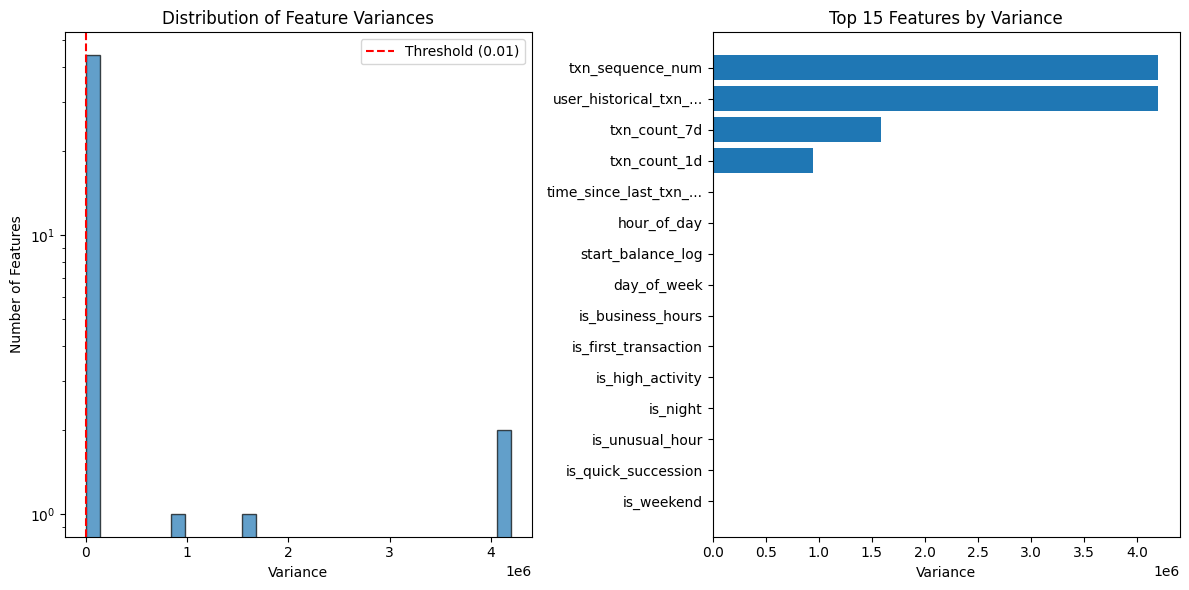


✅ Variance Analysis Complete:
   • Original features: 48
   • Low variance features removed: 30
   • Remaining features: 18


In [ ]:
# 1. Variance Analysis - Remove Low Variance Features
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 1. VARIANCE ANALYSIS")
print("="*50)

# Calculate variance for each feature
feature_variances = X.var().sort_values(ascending=False)
print(f"📈 Feature Variance Statistics:")
print(f"   • Mean variance: {feature_variances.mean():.6f}")
print(f"   • Median variance: {feature_variances.median():.6f}")
print(f"   • Min variance: {feature_variances.min():.6f}")
print(f"   • Max variance: {feature_variances.max():.6f}")

# Identify low variance features (variance < 0.01)
low_variance_threshold = 0.01
low_variance_features = feature_variances[feature_variances < low_variance_threshold].index.tolist()

print(f"\n🔍 Low Variance Features (< {low_variance_threshold}):")
if low_variance_features:
    for i, feature in enumerate(low_variance_features[:10], 1):  # Show first 10
        print(f"   {i:2d}. {feature:<30} | Variance: {feature_variances[feature]:.6f}")
    if len(low_variance_features) > 10:
        print(f"   ... and {len(low_variance_features) - 10} more")
else:
    print("   ✅ No low variance features found!")

# Plot variance distribution
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(feature_variances, bins=30, alpha=0.7, edgecolor='black')
plt.axvline(low_variance_threshold, color='red', linestyle='--', label=f'Threshold ({low_variance_threshold})')
plt.xlabel('Variance')
plt.ylabel('Number of Features')
plt.title('Distribution of Feature Variances')
plt.legend()
plt.yscale('log')

plt.subplot(1, 2, 2)
top_variance_features = feature_variances.head(15)
plt.barh(range(len(top_variance_features)), top_variance_features.values)
plt.yticks(range(len(top_variance_features)), [f"{name[:20]}..." if len(name) > 20 else name for name in top_variance_features.index])
plt.xlabel('Variance')
plt.title('Top 15 Features by Variance')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# Remove low variance features
high_variance_features = [col for col in feature_cols if col not in low_variance_features]
X_variance_filtered = X[high_variance_features]

print(f"\n✅ Variance Analysis Complete:")
print(f"   • Original features: {len(feature_cols)}")
print(f"   • Low variance features removed: {len(low_variance_features)}")
print(f"   • Remaining features: {len(high_variance_features)}")

variance_results = {
    'original_features': len(feature_cols),
    'low_variance_removed': len(low_variance_features),
    'remaining_features': len(high_variance_features),
    'low_variance_features': low_variance_features,
    'high_variance_features': high_variance_features
}


📊 2. CORRELATION ANALYSIS
🔍 Highly Correlated Feature Pairs (|correlation| > 0.6):
    1. txn_sequence_num     - user_historical_txn_ | Corr:  1.000
    2. unique_channels_1d   - multi_channel_recent | Corr:  0.992
    3. unique_channels_1d   - unique_channels_7d   | Corr:  0.980
    4. unique_channels_7d   - multi_channel_recent | Corr:  0.972
    5. txn_count_1d         - txn_count_7d         | Corr:  0.791
    6. is_night             - is_unusual_hour      | Corr:  0.759
    7. is_first_transaction - is_high_activity     | Corr: -0.758
    8. hour_of_day          - is_unusual_hour      | Corr: -0.714
    9. txn_count_1d         - is_high_activity     | Corr:  0.652
   10. txn_sequence_num     - txn_count_7d         | Corr:  0.608
   ... and 1 more pairs

🎯 Top Features Correlated with Target (Fraud):
    1. is_weekend                     | Correlation: 0.5148
    2. txn_sequence_num               | Correlation: 0.2619
    3. user_historical_txn_count      | Correlation: 0.2619
    

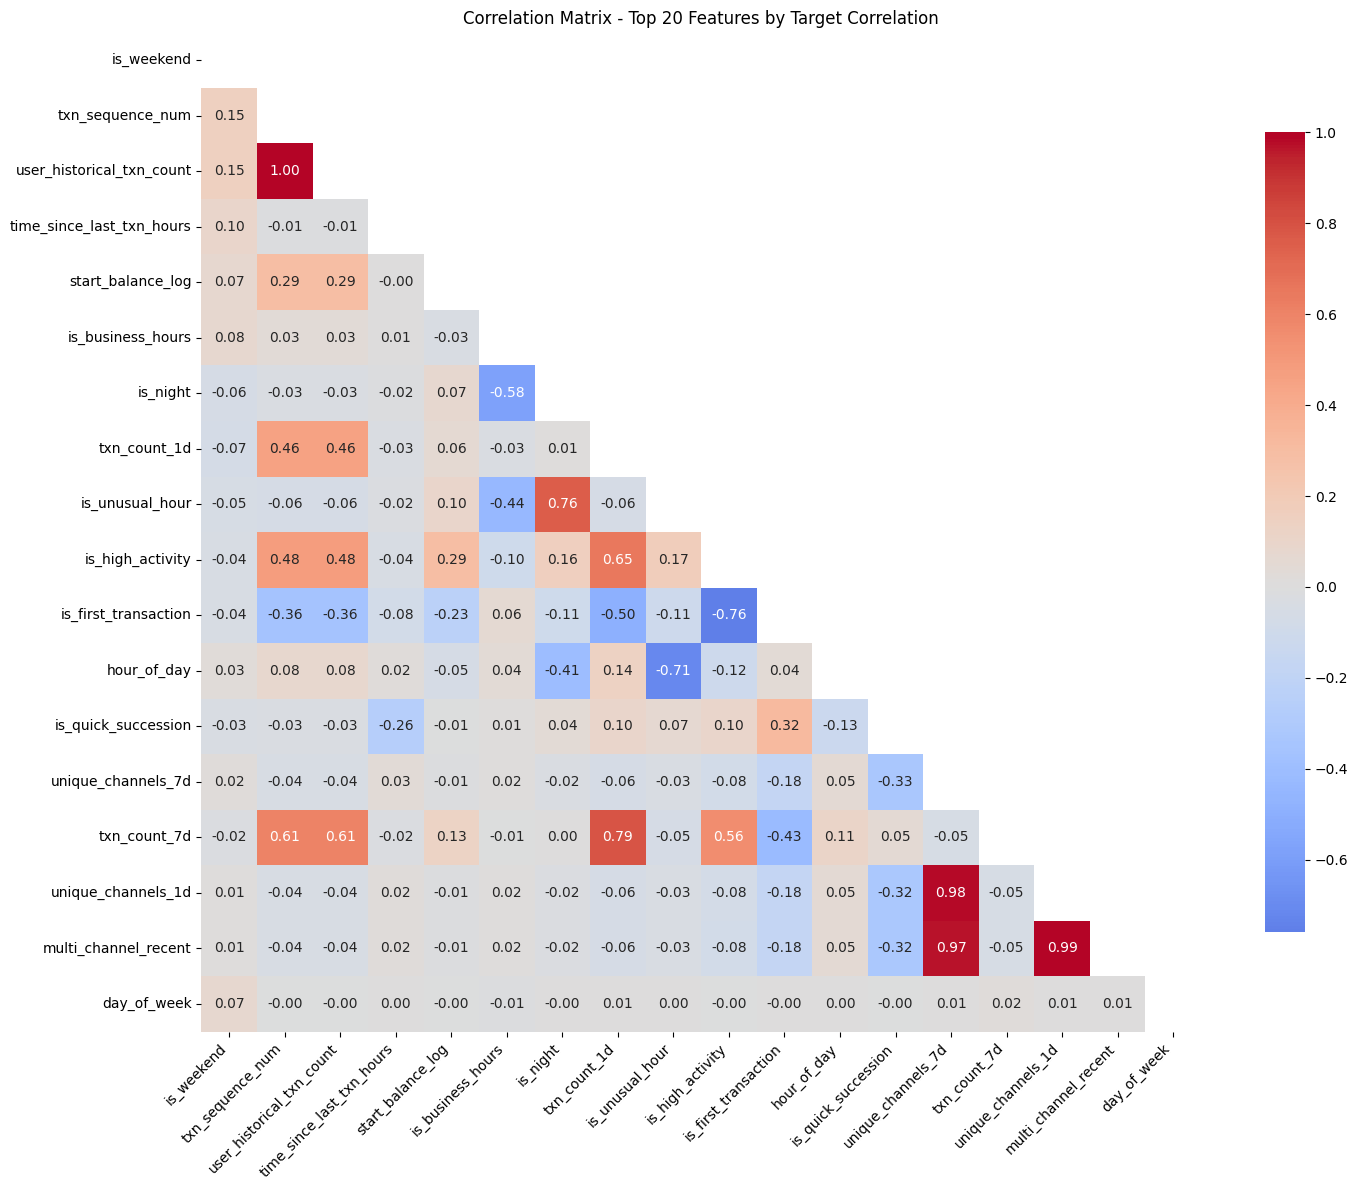


✅ Correlation Analysis Complete:
   • Features after variance filtering: 18
   • Highly correlated pairs found: 11
   • Features removed due to correlation: 8
   • Remaining features: 10


In [23]:
# 2. Correlation Analysis
print("\n📊 2. CORRELATION ANALYSIS")
print("="*50)

# Calculate correlation matrix for high variance features
correlation_matrix = X_variance_filtered.corr()

# Find highly correlated feature pairs
high_corr_threshold = 0.6
highly_correlated_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > high_corr_threshold:
            highly_correlated_pairs.append({
                'feature1': correlation_matrix.columns[i],
                'feature2': correlation_matrix.columns[j],
                'correlation': corr_val
            })

print(f"🔍 Highly Correlated Feature Pairs (|correlation| > {high_corr_threshold}):")
if highly_correlated_pairs:
    highly_correlated_pairs.sort(key=lambda x: abs(x['correlation']), reverse=True)
    for i, pair in enumerate(highly_correlated_pairs[:10], 1):  # Show top 10
        print(f"   {i:2d}. {pair['feature1'][:20]:20} - {pair['feature2'][:20]:20} | Corr: {pair['correlation']:6.3f}")
    if len(highly_correlated_pairs) > 10:
        print(f"   ... and {len(highly_correlated_pairs) - 10} more pairs")
else:
    print("   ✅ No highly correlated features found!")

# Calculate correlation with target variable
target_correlations = X_variance_filtered.corrwith(y).abs().sort_values(ascending=False)

print(f"\n🎯 Top Features Correlated with Target (Fraud):")
for i, (feature, corr) in enumerate(target_correlations.head(15).items(), 1):
    print(f"   {i:2d}. {feature:<30} | Correlation: {corr:.4f}")

# Plot correlation matrix heatmap (for top features)
plt.figure(figsize=(15, 12))

# Select top correlated features for visualization
top_features_for_viz = target_correlations.head(20).index.tolist()
corr_matrix_subset = X_variance_filtered[top_features_for_viz].corr()

mask = np.triu(np.ones_like(corr_matrix_subset, dtype=bool))
sns.heatmap(corr_matrix_subset, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Correlation Matrix - Top 20 Features by Target Correlation')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Remove one feature from each highly correlated pair
features_to_remove_corr = []
for pair in highly_correlated_pairs:
    # Remove the feature with lower target correlation
    corr1 = abs(target_correlations.get(pair['feature1'], 0))
    corr2 = abs(target_correlations.get(pair['feature2'], 0))
    
    if corr1 < corr2:
        if pair['feature1'] not in features_to_remove_corr:
            features_to_remove_corr.append(pair['feature1'])
    else:
        if pair['feature2'] not in features_to_remove_corr:
            features_to_remove_corr.append(pair['feature2'])

# Filter out highly correlated features
correlation_filtered_features = [col for col in X_variance_filtered.columns 
                                if col not in features_to_remove_corr]
X_correlation_filtered = X_variance_filtered[correlation_filtered_features]

print(f"\n✅ Correlation Analysis Complete:")
print(f"   • Features after variance filtering: {len(X_variance_filtered.columns)}")
print(f"   • Highly correlated pairs found: {len(highly_correlated_pairs)}")
print(f"   • Features removed due to correlation: {len(features_to_remove_corr)}")
print(f"   • Remaining features: {len(correlation_filtered_features)}")

correlation_results = {
    'highly_correlated_pairs': len(highly_correlated_pairs),
    'features_removed': len(features_to_remove_corr),
    'remaining_features': len(correlation_filtered_features),
    'target_correlations': target_correlations,
    'removed_features': features_to_remove_corr
}

In [26]:
import subprocess
import sys

# Install required package for VIF analysis

try:
    import statsmodels
    print("✅ statsmodels already installed")
except ImportError:
    print("📦 Installing statsmodels...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels"])
    print("✅ statsmodels installed successfully")

print("🔧 Ready for VIF analysis!")

📦 Installing statsmodels...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/10.7 MB ? eta -:--:--  Downloading patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 18.2 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 18.2 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 1/2 [statsmodels]Installing collected packages: patsy, statsmodels
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]


✅ statsmodels installed successfully
🔧 Ready for VIF analysis!



📊 3. MULTICOLLINEARITY ANALYSIS (VIF)
🔧 Calculating VIF for 10 features...

🔍 VIF Analysis Results:
   • High multicollinearity (VIF > 10.0): 0 features
   • Moderate multicollinearity (VIF 5.0-10.0): 0 features
   • Low multicollinearity (VIF < 5.0): 10 features

📈 Top 15 Features by VIF:
    3. is_night                       | VIF:     1.51 | 🟢 Low
    4. is_business_hours              | VIF:     1.51 | 🟢 Low
    6. txn_sequence_num               | VIF:     1.46 | 🟢 Low
    8. txn_count_1d                   | VIF:     1.33 | 🟢 Low
    7. is_quick_succession            | VIF:     1.23 | 🟢 Low
    9. unique_channels_7d             | VIF:     1.13 | 🟢 Low
   10. start_balance_log              | VIF:     1.11 | 🟢 Low
    5. time_since_last_txn_hours      | VIF:     1.09 | 🟢 Low
    2. is_weekend                     | VIF:     1.07 | 🟢 Low
    1. day_of_week                    | VIF:     1.01 | 🟢 Low


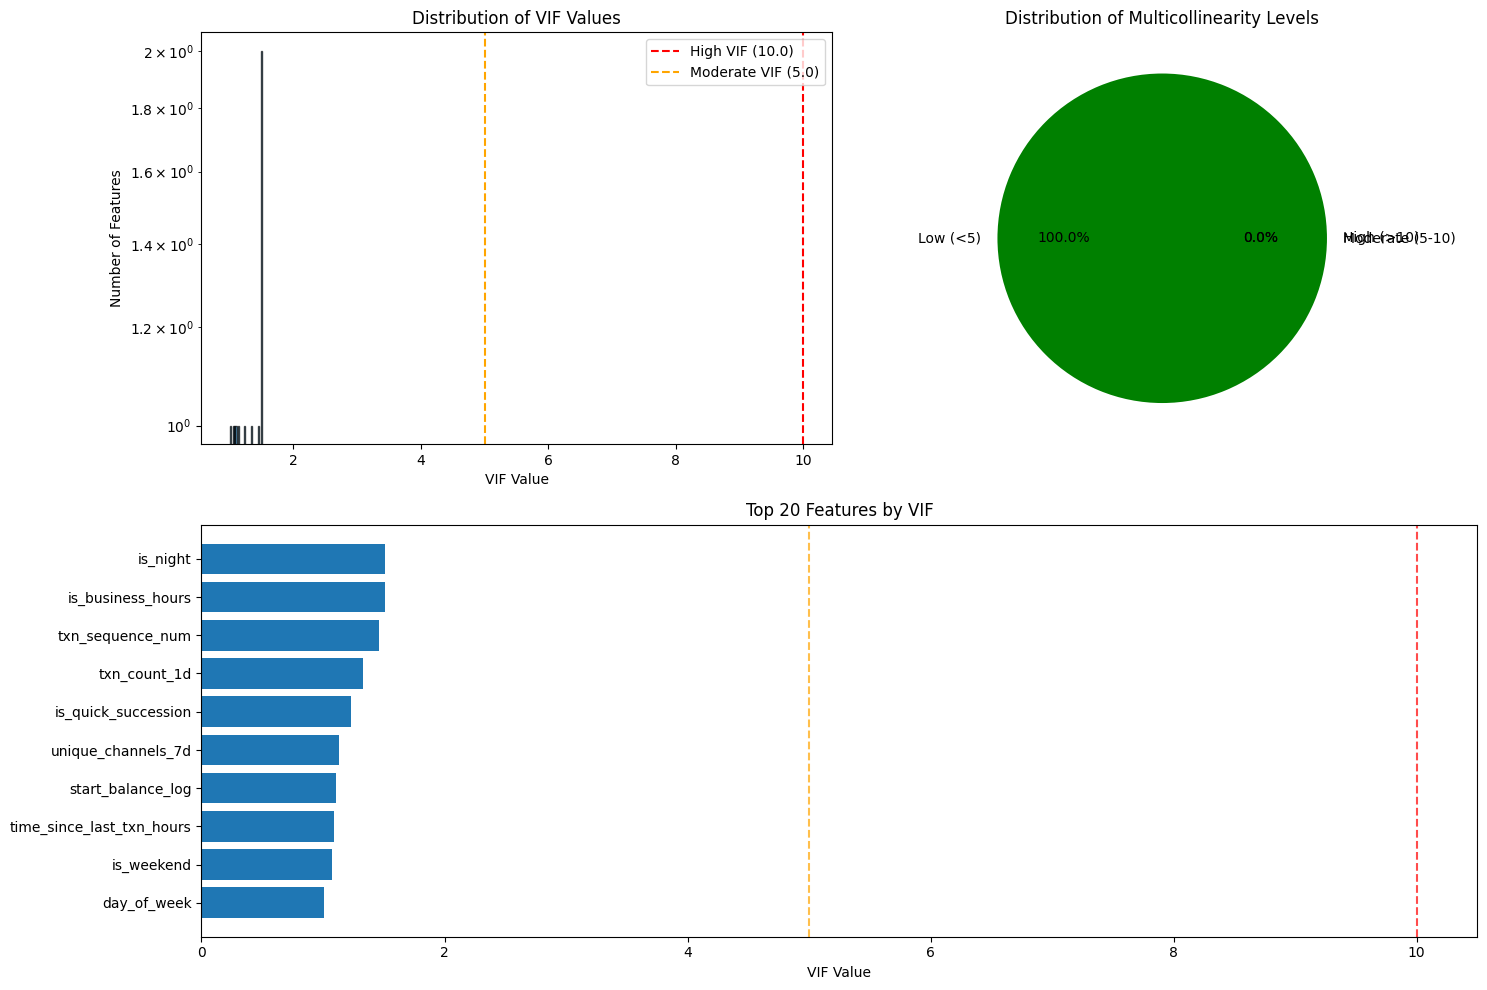


✅ VIF Analysis Complete:
   • Features after correlation filtering: 10
   • Features with high VIF removed: 0
   • Remaining features: 10


In [27]:
# 3. Multicollinearity Check using VIF (Variance Inflation Factor)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

print("\n📊 3. MULTICOLLINEARITY ANALYSIS (VIF)")
print("="*50)

# Prepare data for VIF calculation
# VIF requires no missing values and standardized data
X_vif = X_correlation_filtered.copy()

# Handle any remaining missing values
X_vif = X_vif.fillna(0)

# Standardize the features for VIF calculation
scaler = StandardScaler()
X_vif_scaled = pd.DataFrame(
    scaler.fit_transform(X_vif), 
    columns=X_vif.columns, 
    index=X_vif.index
)

print(f"🔧 Calculating VIF for {len(X_vif_scaled.columns)} features...")

# Calculate VIF for each feature
vif_data = []
for i, feature in enumerate(X_vif_scaled.columns):
    try:
        vif_value = variance_inflation_factor(X_vif_scaled.values, i)
        vif_data.append({
            'Feature': feature,
            'VIF': vif_value
        })
    except Exception as e:
        print(f"   ⚠️  Error calculating VIF for {feature}: {str(e)}")
        vif_data.append({
            'Feature': feature,
            'VIF': np.inf
        })

# Create VIF DataFrame and sort by VIF value
vif_df = pd.DataFrame(vif_data)
vif_df = vif_df.sort_values('VIF', ascending=False)

# Define VIF thresholds
high_vif_threshold = 10.0  # Standard threshold
moderate_vif_threshold = 5.0

high_vif_features = vif_df[vif_df['VIF'] > high_vif_threshold]['Feature'].tolist()
moderate_vif_features = vif_df[(vif_df['VIF'] > moderate_vif_threshold) & 
                               (vif_df['VIF'] <= high_vif_threshold)]['Feature'].tolist()

print(f"\n🔍 VIF Analysis Results:")
print(f"   • High multicollinearity (VIF > {high_vif_threshold}): {len(high_vif_features)} features")
print(f"   • Moderate multicollinearity (VIF {moderate_vif_threshold}-{high_vif_threshold}): {len(moderate_vif_features)} features")
print(f"   • Low multicollinearity (VIF < {moderate_vif_threshold}): {len(vif_df) - len(high_vif_features) - len(moderate_vif_features)} features")

print(f"\n📈 Top 15 Features by VIF:")
for i, row in vif_df.head(15).iterrows():
    vif_status = "🔴 High" if row['VIF'] > high_vif_threshold else ("🟡 Moderate" if row['VIF'] > moderate_vif_threshold else "🟢 Low")
    print(f"   {i+1:2d}. {row['Feature']:<30} | VIF: {row['VIF']:8.2f} | {vif_status}")

# Plot VIF distribution
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
# Remove infinite values for plotting
vif_finite = vif_df[np.isfinite(vif_df['VIF'])]['VIF']
plt.hist(vif_finite, bins=30, alpha=0.7, edgecolor='black')
plt.axvline(high_vif_threshold, color='red', linestyle='--', label=f'High VIF ({high_vif_threshold})')
plt.axvline(moderate_vif_threshold, color='orange', linestyle='--', label=f'Moderate VIF ({moderate_vif_threshold})')
plt.xlabel('VIF Value')
plt.ylabel('Number of Features')
plt.title('Distribution of VIF Values')
plt.legend()
plt.yscale('log')

plt.subplot(2, 2, 2)
vif_categories = ['Low (<5)', 'Moderate (5-10)', 'High (>10)']
vif_counts = [
    len(vif_df) - len(high_vif_features) - len(moderate_vif_features),
    len(moderate_vif_features),
    len(high_vif_features)
]
colors = ['green', 'orange', 'red']
plt.pie(vif_counts, labels=vif_categories, colors=colors, autopct='%1.1f%%')
plt.title('Distribution of Multicollinearity Levels')

plt.subplot(2, 1, 2)
# Plot top 20 VIF values
top_vif = vif_df.head(20)
top_vif_finite = top_vif[np.isfinite(top_vif['VIF'])]
plt.barh(range(len(top_vif_finite)), top_vif_finite['VIF'])
plt.yticks(range(len(top_vif_finite)), [f"{name[:25]}..." if len(name) > 25 else name for name in top_vif_finite['Feature']])
plt.xlabel('VIF Value')
plt.title('Top 20 Features by VIF')
plt.axvline(high_vif_threshold, color='red', linestyle='--', alpha=0.7)
plt.axvline(moderate_vif_threshold, color='orange', linestyle='--', alpha=0.7)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# Remove features with extremely high VIF (> 10)
low_vif_features = vif_df[vif_df['VIF'] <= high_vif_threshold]['Feature'].tolist()
X_vif_filtered = X_correlation_filtered[low_vif_features]

print(f"\n✅ VIF Analysis Complete:")
print(f"   • Features after correlation filtering: {len(X_correlation_filtered.columns)}")
print(f"   • Features with high VIF removed: {len(high_vif_features)}")
print(f"   • Remaining features: {len(low_vif_features)}")

vif_results = {
    'vif_dataframe': vif_df,
    'high_vif_features': high_vif_features,
    'remaining_features': len(low_vif_features),
    'vif_threshold_used': high_vif_threshold
}

In [30]:
import subprocess
import sys

# Install SHAP package for feature importance analysis

try:
    import shap
    print("✅ SHAP already installed")
except ImportError:
    print("📦 Installing SHAP...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    print("✅ SHAP installed successfully")

print("🔧 Ready for SHAP analysis!")

📦 Installing SHAP...
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.0 MB ? eta -:--:--Collecting llvmlite<0.46,>=0.45.0dev0 (from numba>=0.54->shap)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 11.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 44.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 11.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 44.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/56.3 MB ? eta -:--:--Downloading llvmlite-0.45.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (56.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 112.0 MB/s  0:00:00 eta 0:00:01
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 112.0 MB/s  0:00:00 eta 0:00:01
Using cached tqdm-4.67.1-py3-none-an

# 📚 Comprehensive Feature Description Guide

This section provides detailed descriptions of all features created in the fraud detection pipeline, organized by category and purpose.

## 🕒 **1. TEMPORAL FEATURES**
These features capture time-based patterns that are crucial for fraud detection.

### **Basic Time Features**
- **`hour_of_day`** (0-23): Hour when transaction occurred
  - *Fraud Relevance*: Fraudsters often operate during unusual hours (late night/early morning)
  - *Business Logic*: Normal users typically transact during business hours

- **`day_of_week`** (1-7): Day of week (1=Sunday, 7=Saturday)  
  - *Fraud Relevance*: Weekend patterns differ from weekdays
  - *Business Logic*: Legitimate business transactions follow weekly patterns

### **Time-Based Risk Indicators**
- **`is_weekend`** (0/1): Binary flag for weekend transactions
  - *Fraud Relevance*: Higher fraud rates on weekends when monitoring is reduced
  - *Calculation*: 1 if day_of_week is 1 (Sunday) or 7 (Saturday)

- **`is_night`** (0/1): Binary flag for night transactions (10 PM - 6 AM)
  - *Fraud Relevance*: Night transactions are statistically more suspicious
  - *Calculation*: 1 if hour ≥ 22 OR hour ≤ 6

- **`is_business_hours`** (0/1): Binary flag for business hours (9 AM - 5 PM)
  - *Fraud Relevance*: Legitimate business transactions peak during these hours
  - *Calculation*: 1 if hour is between 9 and 17

- **`is_unusual_hour`** (0/1): Flag for extremely unusual hours (before 6 AM or after 11 PM)
  - *Fraud Relevance*: Very late/early transactions have higher fraud probability
  - *Calculation*: 1 if hour < 6 OR hour > 23

## 📺 **2. CHANNEL FEATURES (One-Hot Encoded)**
These features represent the transaction channels through which transactions are initiated.

### **Channel Categories & Fraud Risk**

**🔴 HIGH RISK CHANNELS:**
- **`CHANNEL_CASH_OUT`**: Cash withdrawal transactions
  - *Fraud Pattern*: Final step in money laundering, converts digital to physical cash
  - *Risk Level*: Very High - often the end goal of fraud schemes

- **`CHANNEL_TRANSFER_C2C`**: Customer-to-Customer transfers  
  - *Fraud Pattern*: Used to quickly move stolen funds between accounts
  - *Risk Level*: High - enables rapid fund dispersion

- **`CHANNEL_IBFT_OUTGOING_OTC`**: Over-The-Counter Inter-Bank Fund Transfers
  - *Fraud Pattern*: Anonymous transfers to external banks, harder to trace
  - *Risk Level*: High - cross-bank transfers complicate investigation

**🟡 MEDIUM RISK CHANNELS:**
- **`CHANNEL_ONLINE_PAYMENT`**: Online payment transactions
  - *Fraud Pattern*: Card-not-present fraud, stolen credentials
  - *Risk Level*: Medium - depends on merchant verification

- **`CHANNEL_MERCHANT_PAYMENT`**: Payments to merchants
  - *Fraud Pattern*: Fraudulent purchases with stolen accounts
  - *Risk Level*: Medium - varies by merchant type

- **`CHANNEL_TRANSFER_C2B`**: Customer-to-Business transfers
  - *Fraud Pattern*: Fake business payments, invoice fraud
  - *Risk Level*: Medium - business verification reduces risk

**🟢 LOWER RISK CHANNELS:**
- **`CHANNEL_UTILITY_BILLS_PAYMENT`**: Utility bill payments
  - *Fraud Pattern*: Less attractive to fraudsters (personal bills)
  - *Risk Level*: Lower - typically personal, verified accounts

- **`CHANNEL_JAZZ_LOAD_PREPAID_TOP_UP`**: Mobile top-up transactions
  - *Fraud Pattern*: Small amounts, less attractive for large fraud
  - *Risk Level*: Lower - small transaction amounts

- **`CHANNEL_CASH_IN`**: Cash deposit transactions  
  - *Fraud Pattern*: Rare - adds funds rather than extracting
  - *Risk Level*: Lower - opposite direction of typical fraud

**⚪ ADMINISTRATIVE CHANNELS:**
- **`CHANNEL_GET_LOAN`**: Loan disbursement transactions
- **`CHANNEL_TRANSFER_B2C`**: Business-to-Customer transfers  
- **`CHANNEL_IBFT_OUTGOING_CUSTOMER`**: Regular inter-bank transfers
- **`CHANNEL_MFS_CARD_WITHDRAW`**: Card-based withdrawals

## 🛠️ **3. TRANSACTION TYPE FEATURES (One-Hot Encoded)**
These features represent the technical method or interface used for the transaction.

### **Transaction Type Categories & Risk Assessment**

**🔴 HIGH RISK TYPES:**
- **`TYPE_API`**: Direct API calls
  - *Fraud Pattern*: Automated attacks, bot-driven transactions
  - *Risk Level*: Very High - can execute rapid, high-volume fraud

- **`TYPE_THIRD_PARTY_WEB`**: Third-party web integrations  
  - *Fraud Pattern*: Compromised merchant sites, man-in-the-middle attacks
  - *Risk Level*: High - less controlled environment

- **`TYPE_PAYMENT_GATEWAY`**: Payment gateway transactions
  - *Fraud Pattern*: Stolen card details, account takeovers
  - *Risk Level*: High - common target for fraudsters

**🟡 MEDIUM RISK TYPES:**
- **`TYPE_MOBILE_APP`**: Mobile application transactions
  - *Fraud Pattern*: App-based account takeovers, stolen devices
  - *Risk Level*: Medium - depends on app security

- **`TYPE_NEW_JC_APP`**: New JazzCash application interface
  - *Fraud Pattern*: New interface may have security gaps
  - *Risk Level*: Medium - emerging platform risks

- **`TYPE_USSD`**: USSD (Unstructured Supplementary Service Data)
  - *Fraud Pattern*: SIM swap attacks, stolen phones
  - *Risk Level*: Medium - tied to physical SIM cards

**🟢 LOWER RISK TYPES:**
- **`TYPE_SELF_CARE_APP`**: Self-service application transactions
  - *Fraud Pattern*: Authenticated user actions
  - *Risk Level*: Lower - user-initiated, authenticated

- **`TYPE_ATM`**: ATM transactions
  - *Fraud Pattern*: Physical card required, PIN verification
  - *Risk Level*: Lower - physical authentication required

- **`TYPE_BIO`**: Biometric authentication transactions
  - *Fraud Pattern*: Very difficult to fake biometric data
  - *Risk Level*: Very Low - strongest authentication

**⚪ SPECIALIZED TYPES:**
- **`TYPE_USSD_API`**: USSD API integration
- **`TYPE_QR_PAYMENT`**: QR code-based payments  
- **`TYPE_BISP`**: BISP (social welfare) transactions
- **`TYPE_BUSINESS_APP`**: Business application transactions
- **`TYPE_BUSINESS_APP_API`**: Business API transactions
- **`TYPE_CHEETAY`**: Cheetay delivery service integration
- **`TYPE_VRG`**: VRG (specific service) transactions

## ⏰ **4. SEQUENCE & TEMPORAL RELATIONSHIP FEATURES**
These features capture the temporal relationships between consecutive transactions.

### **Transaction Sequence Features**
- **`time_since_last_txn_hours`** (Continuous): Hours since user's previous transaction
  - *Fraud Relevance*: Rapid-fire transactions indicate automated fraud or account takeover
  - *Normal Pattern*: Users typically have gaps between legitimate transactions
  - *Fraud Pattern*: Values close to 0 suggest scripted attacks

- **`txn_sequence_num`** (1, 2, 3, ...): Sequential transaction number for each user
  - *Fraud Relevance*: Early transactions in compromised accounts are often fraudulent
  - *Business Logic*: New users have different risk profiles than established users
  - *Usage*: Combined with other features to detect account takeover timing

### **Rapid Transaction Indicators**  
- **`is_quick_succession`** (0/1): Flag for transactions within 1 hour of previous
  - *Fraud Relevance*: Fraudsters often execute multiple quick transactions
  - *Calculation*: 1 if time_since_last_txn_hours < 1
  - *Risk Level*: High - legitimate users rarely transact so frequently

- **`is_first_transaction`** (0/1): Flag for user's very first transaction
  - *Fraud Relevance*: New accounts may be created specifically for fraud
  - *Business Logic*: First transactions have different risk profiles
  - *Calculation*: 1 if txn_sequence_num = 1

## 🚀 **5. VELOCITY FEATURES** 
These features measure user activity intensity over different time windows.

### **Transaction Count Velocity**
- **`txn_count_1d`** (0, 1, 2, ...): Number of transactions in past 24 hours
  - *Fraud Relevance*: Sudden spikes indicate account compromise or automated attacks
  - *Normal Range*: Most users: 1-3 transactions/day
  - *Fraud Pattern*: Values >5 highly suspicious, >10 almost certainly fraud

- **`txn_count_7d`** (0, 1, 2, ...): Number of transactions in past 7 days  
  - *Fraud Relevance*: Weekly activity patterns, sustained fraud campaigns
  - *Business Logic*: Establishes user's normal activity baseline
  - *Risk Threshold*: >20 transactions in 7 days warrants investigation

### **Channel Diversity Velocity**
- **`unique_channels_1d`** (0, 1, 2, ...): Number of different channels used in past 24 hours
  - *Fraud Relevance*: Fraudsters test multiple channels after account takeover
  - *Normal Pattern*: Users typically stick to 1-2 preferred channels daily
  - *Fraud Pattern*: Using 3+ channels in one day is highly suspicious

- **`unique_channels_7d`** (0, 1, 2, ...): Number of different channels used in past 7 days
  - *Fraud Relevance*: Shows if user suddenly changed behavior patterns
  - *Baseline Establishment*: Helps understand user's normal channel preferences
  - *Risk Indicator*: Sudden increase suggests account compromise

## 👤 **6. BEHAVIORAL PROFILE FEATURES**
These features capture user's historical behavior patterns and deviations.

### **Historical Activity Patterns**
- **`user_historical_txn_count`** (0, 1, 2, ...): Total historical transactions before current transaction
  - *Fraud Relevance*: New accounts with little history are riskier
  - *Business Logic*: Established users have predictable patterns
  - *Risk Assessment*: Accounts with <5 historical transactions need extra scrutiny
  - *Usage*: Combined with current activity to detect behavioral changes

### **Behavioral Anomaly Indicators**
- **`is_unusual_hour`** (0/1): Extreme time anomaly flag (before 6 AM or after 11 PM)
  - *Fraud Relevance*: Legitimate users rarely transact at these extreme hours
  - *Calculation*: 1 if hour < 6 OR hour > 23
  - *Risk Level*: Very High - strong fraud indicator
  - *Difference from is_night**: More restrictive time window for extreme cases

## 🔥 **7. COMPOSITE RISK INDICATORS**
These features combine multiple signals to create high-level risk indicators.

### **Activity Risk Flags**
- **`is_high_activity`** (0/1): Flag for unusually high transaction volume
  - *Fraud Relevance*: Sudden activity spikes often indicate account compromise
  - *Calculation*: 1 if txn_count_1d > 5
  - *Business Logic*: Most legitimate users don't exceed 5 transactions daily
  - *Risk Level*: High - triggers immediate review

### **Contextual Risk Combinations**
- **`night_weekend_combo`** (0/1): High-risk time combination flag
  - *Fraud Relevance*: Night + Weekend = minimal monitoring + unusual timing
  - *Calculation*: 1 if (is_night = 1 AND is_weekend = 1)
  - *Risk Logic*: Double risk factor - both time dimensions are suspicious
  - *Usage**: Often combined with other indicators for fraud scoring

- **`multi_channel_recent`** (0/1): Recent channel switching behavior
  - *Fraud Relevance*: Fraudsters test multiple channels after account takeover
  - *Calculation*: 1 if unique_channels_1d > 1  
  - *Normal Pattern*: Users typically stick to preferred channels
  - *Investigation Trigger**: When combined with other risk factors

## 💰 **8. FINANCIAL FEATURES**
These features are derived from transaction amounts and account balances.

### **Balance-Based Features**
- **`start_balance_log`** (Continuous): Log-transformed starting account balance
  - *Fraud Relevance*: Account balance affects fraud attractiveness and capability  
  - *Transformation Logic*: log1p(balance) handles zero balances and reduces skewness
  - *Risk Assessment*: 
    - Very low balances: May indicate compromised/drained accounts
    - Very high balances: More attractive targets for fraudsters
  - *Business Logic*: Balance patterns help establish user financial behavior

## 🎯 **9. TARGET VARIABLE**
The prediction target for the machine learning model.

### **Fraud Label**
- **`label`** (0/1): Binary fraud indicator
  - **0**: Legitimate transaction (negative class)  
  - **1**: Fraudulent transaction (positive class)
  - *Data Source*: Derived from known fraud cases in `stixor_iar_jul_fraud_only_with_mbar` table
  - *Class Balance*: Typically imbalanced (fraud is rare), requiring balanced sampling or class weighting

## 📈 **FEATURE ENGINEERING STRATEGY SUMMARY**

### **🎯 Core Fraud Detection Principles**

**1. Temporal Anomaly Detection**
- Unusual timing patterns (nights, weekends, extreme hours)
- Rapid transaction sequences indicating automated attacks
- Time-based behavioral changes

**2. Velocity-Based Risk Assessment** 
- Transaction frequency spikes
- Channel switching behavior  
- Activity pattern deviations

**3. Behavioral Profile Analysis**
- Historical vs. current activity comparison
- User establishment and credibility metrics
- Behavioral consistency evaluation

**4. Multi-Signal Risk Indicators**
- Composite flags combining multiple risk factors
- Cross-feature validation and correlation
- Hierarchical risk scoring

### **🔧 Technical Implementation Notes**

**Encoding Strategy:**
- One-hot encoding for categorical variables (channels, types)
- Binary flags for risk indicators
- Log transformation for skewed numerical features  
- Time-based window calculations using Spark Window functions

**Performance Optimizations:**
- Limited window functions to essential time periods (1d, 7d)
- Streamlined feature set to avoid execution plan complexity
- Efficient Spark operations with proper partitioning

**Feature Selection Considerations:**
- Variance filtering to remove low-information features
- Correlation analysis to eliminate redundant features  
- VIF analysis to detect multicollinearity
- SHAP importance for model-agnostic feature ranking

In [32]:
# 4. SHAP Analysis for Feature Importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import shap
import warnings
warnings.filterwarnings('ignore')

print("\n📊 4. SHAP FEATURE IMPORTANCE ANALYSIS")
print("="*50)

# Prepare final feature set for SHAP analysis
X_final = X_vif_filtered.copy()
y_final = y.copy()

# Split the data for model training
X_train_shap, X_test_shap, y_train_shap, y_test_shap = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

print(f"🔧 Training model for SHAP analysis...")
print(f"   • Training samples: {len(X_train_shap):,}")
print(f"   • Test samples: {len(X_test_shap):,}")
print(f"   • Features: {len(X_final.columns)}")

# Train a Random Forest model for SHAP analysis
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_model.fit(X_train_shap, y_train_shap)

# Calculate model performance
train_score = rf_model.score(X_train_shap, y_train_shap)
test_score = rf_model.score(X_test_shap, y_test_shap)

print(f"🎯 Model Performance:")
print(f"   • Training Accuracy: {train_score:.4f}")
print(f"   • Test Accuracy: {test_score:.4f}")

# Calculate SHAP values
print(f"\n🔍 Calculating SHAP values...")

# Use TreeExplainer for Random Forest
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for a sample (to avoid memory issues with large datasets)
shap_sample_size = min(1000, len(X_test_shap))
X_shap_sample = X_test_shap.sample(n=shap_sample_size, random_state=42)

shap_values = explainer.shap_values(X_shap_sample)

# For binary classification, take the positive class SHAP values
if len(shap_values) == 2:
    shap_values_positive = shap_values[1]  # Fraud class (positive class)
else:
    # Handle the case where shap_values is 3D array
    if len(shap_values.shape) == 3:
        shap_values_positive = shap_values[:, :, 1]  # Take positive class
    else:
        shap_values_positive = shap_values

print(f"✅ SHAP values calculated for {shap_sample_size} samples")
print(f"   • SHAP values shape: {shap_values_positive.shape}")

# Calculate feature importance from SHAP values
feature_importance_shap = pd.DataFrame({
    'Feature': X_final.columns,
    'SHAP_Importance': np.abs(shap_values_positive).mean(axis=0)
}).sort_values('SHAP_Importance', ascending=False)

print(f"\n🏆 Top 20 Features by SHAP Importance:")
for i, row in feature_importance_shap.head(20).iterrows():
    print(f"   {i+1:2d}. {row['Feature']:<30} | SHAP: {row['SHAP_Importance']:.6f}")

# Compare with Random Forest feature importance
rf_feature_importance = pd.DataFrame({
    'Feature': X_final.columns,
    'RF_Importance': rf_model.feature_importances_
}).sort_values('RF_Importance', ascending=False)

print(f"\n🌳 Top 20 Features by Random Forest Importance:")
for i, row in rf_feature_importance.head(20).iterrows():
    print(f"   {i+1:2d}. {row['Feature']:<30} | RF: {row['RF_Importance']:.6f}")

# Create comprehensive feature importance comparison
feature_comparison = feature_importance_shap.merge(
    rf_feature_importance, on='Feature'
).merge(
    target_correlations.reset_index().rename(columns={'index': 'Feature', 0: 'Target_Correlation'}), 
    on='Feature'
)

# Add ranking columns
feature_comparison['SHAP_Rank'] = feature_comparison['SHAP_Importance'].rank(ascending=False)
feature_comparison['RF_Rank'] = feature_comparison['RF_Importance'].rank(ascending=False)
feature_comparison['Corr_Rank'] = feature_comparison['Target_Correlation'].abs().rank(ascending=False)

# Calculate average rank for final ranking
feature_comparison['Avg_Rank'] = (
    feature_comparison['SHAP_Rank'] + 
    feature_comparison['RF_Rank'] + 
    feature_comparison['Corr_Rank']
) / 3

feature_comparison = feature_comparison.sort_values('Avg_Rank')

print(f"\n🎖️  Top 15 Features by Combined Ranking (SHAP + RF + Correlation):")
for i, row in feature_comparison.head(15).iterrows():
    print(f"   {i+1:2d}. {row['Feature']:<25} | Avg Rank: {row['Avg_Rank']:5.1f} | "
          f"SHAP: {row['SHAP_Importance']:.4f} | RF: {row['RF_Importance']:.4f} | "
          f"Corr: {row['Target_Correlation']:.4f}")

shap_results = {
    'feature_importance_shap': feature_importance_shap,
    'rf_feature_importance': rf_feature_importance,
    'feature_comparison': feature_comparison,
    'model_performance': {'train_score': train_score, 'test_score': test_score}
}


📊 4. SHAP FEATURE IMPORTANCE ANALYSIS
🔧 Training model for SHAP analysis...
   • Training samples: 40,000
   • Test samples: 10,000
   • Features: 10
🎯 Model Performance:
   • Training Accuracy: 0.9801
   • Test Accuracy: 0.9789

🔍 Calculating SHAP values...
🎯 Model Performance:
   • Training Accuracy: 0.9801
   • Test Accuracy: 0.9789

🔍 Calculating SHAP values...
✅ SHAP values calculated for 1000 samples
   • SHAP values shape: (1000, 10)

🏆 Top 20 Features by SHAP Importance:
   10. day_of_week                    | SHAP: 0.257376
    8. time_since_last_txn_hours      | SHAP: 0.056748
    7. start_balance_log              | SHAP: 0.051244
    4. txn_count_1d                   | SHAP: 0.051022
    9. is_weekend                     | SHAP: 0.047583
    3. txn_sequence_num               | SHAP: 0.025310
    2. is_business_hours              | SHAP: 0.023461
    1. is_night                       | SHAP: 0.007480
    5. is_quick_succession            | SHAP: 0.003178
    6. unique_channe


📈 Creating SHAP Visualizations...


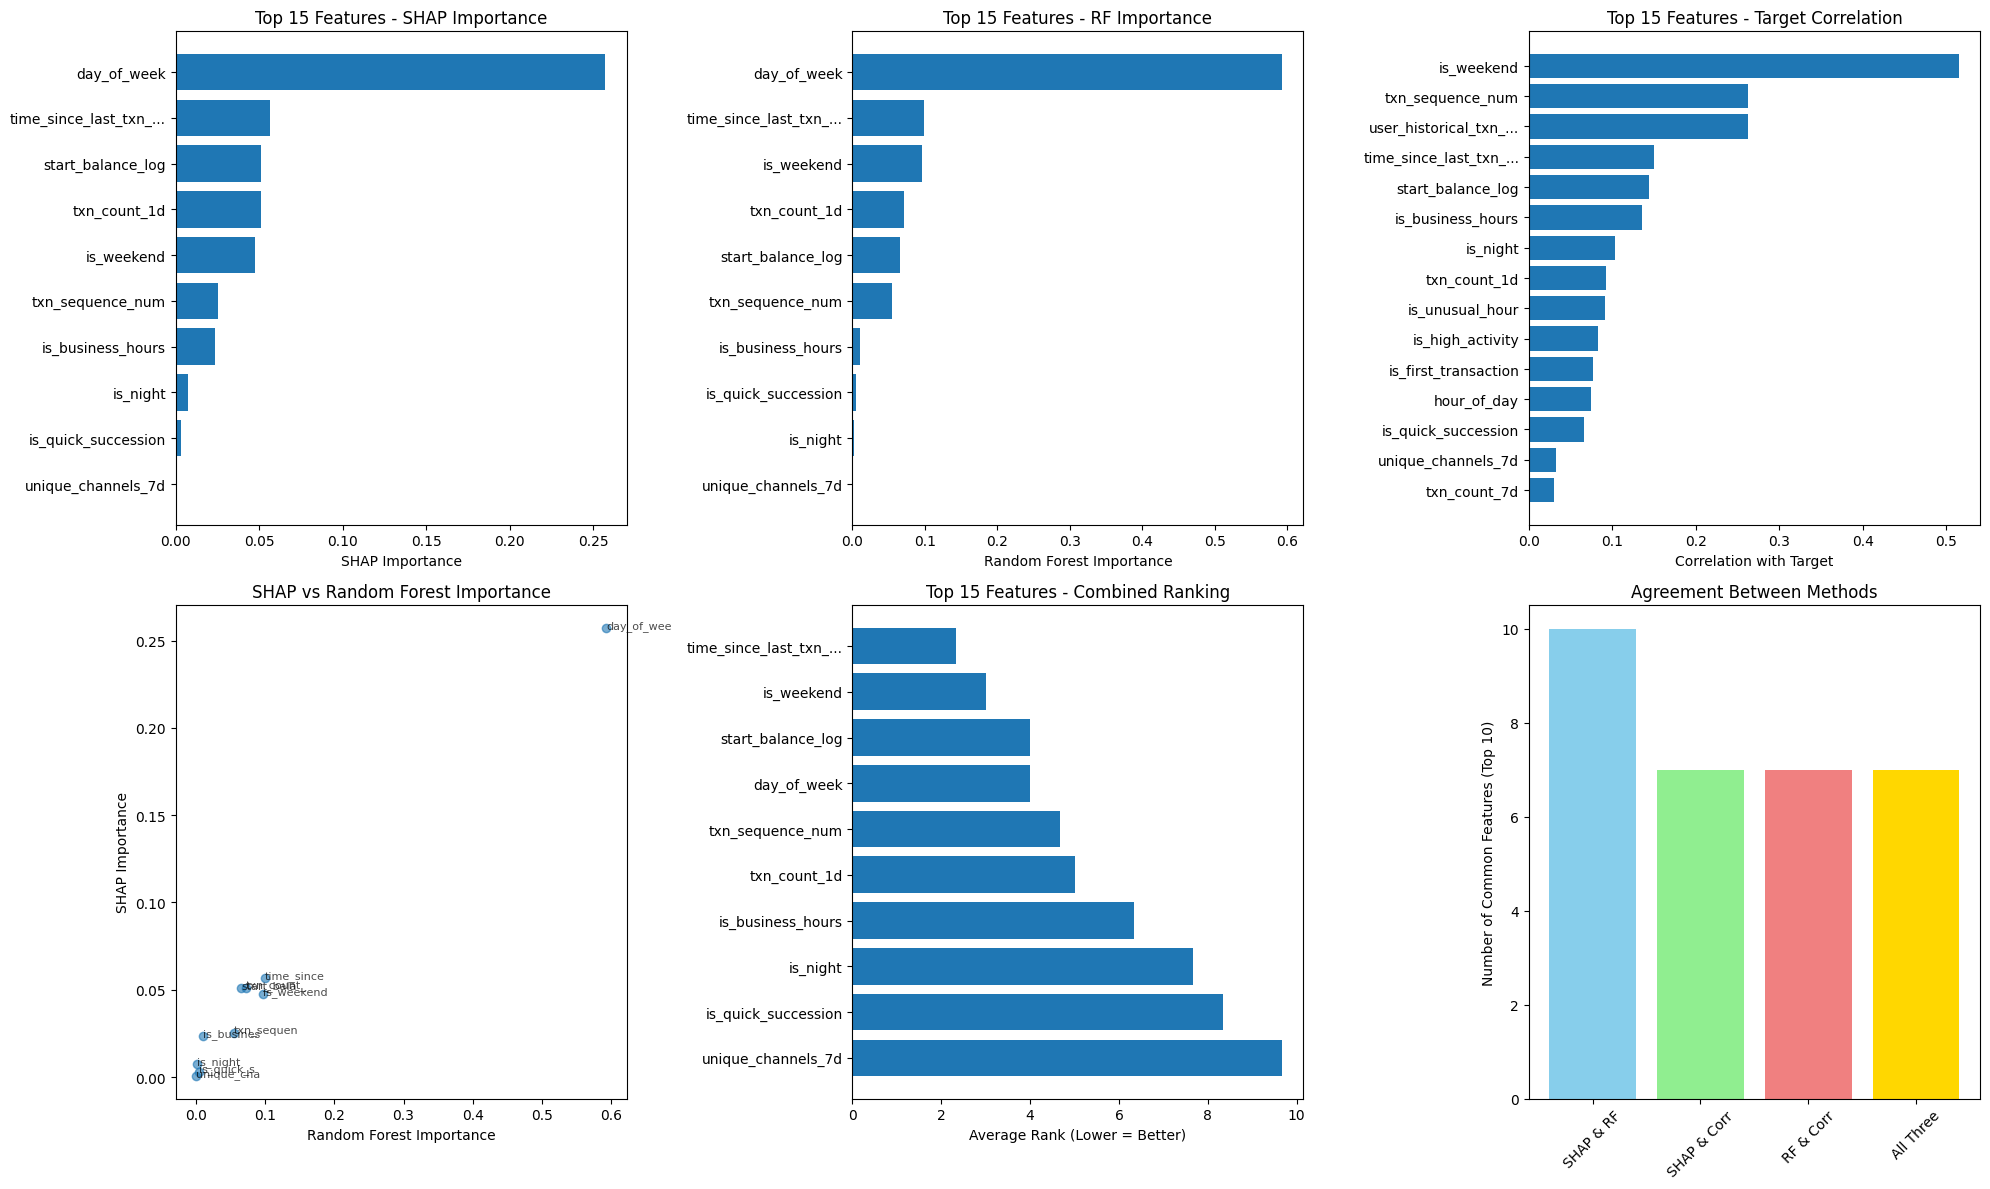

✅ SHAP visualizations complete!


In [33]:
# SHAP Visualizations
print("\n📈 Creating SHAP Visualizations...")

# Create a comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. SHAP Feature Importance (Bar Plot)
top_features_shap = feature_importance_shap.head(15)
axes[0, 0].barh(range(len(top_features_shap)), top_features_shap['SHAP_Importance'])
axes[0, 0].set_yticks(range(len(top_features_shap)))
axes[0, 0].set_yticklabels([f"{name[:20]}..." if len(name) > 20 else name for name in top_features_shap['Feature']])
axes[0, 0].set_xlabel('SHAP Importance')
axes[0, 0].set_title('Top 15 Features - SHAP Importance')
axes[0, 0].invert_yaxis()

# 2. Random Forest Feature Importance
top_features_rf = rf_feature_importance.head(15)
axes[0, 1].barh(range(len(top_features_rf)), top_features_rf['RF_Importance'])
axes[0, 1].set_yticks(range(len(top_features_rf)))
axes[0, 1].set_yticklabels([f"{name[:20]}..." if len(name) > 20 else name for name in top_features_rf['Feature']])
axes[0, 1].set_xlabel('Random Forest Importance')
axes[0, 1].set_title('Top 15 Features - RF Importance')
axes[0, 1].invert_yaxis()

# 3. Target Correlation
top_features_corr = target_correlations.head(15)
axes[0, 2].barh(range(len(top_features_corr)), top_features_corr.values)
axes[0, 2].set_yticks(range(len(top_features_corr)))
axes[0, 2].set_yticklabels([f"{name[:20]}..." if len(name) > 20 else name for name in top_features_corr.index])
axes[0, 2].set_xlabel('Correlation with Target')
axes[0, 2].set_title('Top 15 Features - Target Correlation')
axes[0, 2].invert_yaxis()

# 4. SHAP vs RF Importance Scatter
axes[1, 0].scatter(feature_comparison['RF_Importance'], feature_comparison['SHAP_Importance'], alpha=0.6)
axes[1, 0].set_xlabel('Random Forest Importance')
axes[1, 0].set_ylabel('SHAP Importance')
axes[1, 0].set_title('SHAP vs Random Forest Importance')

# Add labels for top features
top_combined = feature_comparison.head(10)
for _, row in top_combined.iterrows():
    axes[1, 0].annotate(row['Feature'][:10], (row['RF_Importance'], row['SHAP_Importance']), 
                       fontsize=8, alpha=0.7)

# 5. Combined Ranking
top_combined_rank = feature_comparison.head(15)
axes[1, 1].barh(range(len(top_combined_rank)), top_combined_rank['Avg_Rank'])
axes[1, 1].set_yticks(range(len(top_combined_rank)))
axes[1, 1].set_yticklabels([f"{name[:20]}..." if len(name) > 20 else name for name in top_combined_rank['Feature']])
axes[1, 1].set_xlabel('Average Rank (Lower = Better)')
axes[1, 1].set_title('Top 15 Features - Combined Ranking')
axes[1, 1].invert_yaxis()

# 6. Method Agreement
method_agreement = []
top_10_shap = set(feature_importance_shap.head(10)['Feature'])
top_10_rf = set(rf_feature_importance.head(10)['Feature'])
top_10_corr = set(target_correlations.head(10).index)

method_agreement.append(len(top_10_shap & top_10_rf))  # SHAP & RF
method_agreement.append(len(top_10_shap & top_10_corr))  # SHAP & Corr
method_agreement.append(len(top_10_rf & top_10_corr))  # RF & Corr
method_agreement.append(len(top_10_shap & top_10_rf & top_10_corr))  # All three

method_labels = ['SHAP & RF', 'SHAP & Corr', 'RF & Corr', 'All Three']
axes[1, 2].bar(method_labels, method_agreement, color=['skyblue', 'lightgreen', 'lightcoral', 'gold'])
axes[1, 2].set_ylabel('Number of Common Features (Top 10)')
axes[1, 2].set_title('Agreement Between Methods')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"✅ SHAP visualizations complete!")

## 📋 Final Feature Selection Recommendations

Based on the comprehensive analysis above, we'll create an optimal feature set by combining insights from multiple methods.

In [38]:
# Final Feature Selection Strategy
print("🎯 Creating Optimal Feature Set...")

# Define selection thresholds
variance_threshold = 0.001
correlation_threshold = 0.6
vif_threshold = 8.0

# Start with all features
selected_features = set(feature_comparison['Feature'])

# Apply variance filter - only on numeric feature columns
df_features = train_df
numeric_feature_cols = [col for col in feature_cols if col in df_features.columns]

# Calculate variance for numeric features only
variances = {}
for col in numeric_feature_cols:
    try:
        col_var = df_features.select(col).toPandas()[col].var()
        if col_var < variance_threshold:
            variances[col] = col_var
    except (TypeError, ValueError):
        # Skip columns that can't be converted to numeric
        continue

low_var_names = list(variances.keys())
selected_features -= set(low_var_names)
print(f"❌ Removed {len(low_var_names)} low variance features")

# Apply VIF filter (remove features with VIF > threshold)
if len(vif_df) > 0:
    high_vif_features = vif_df[vif_df['VIF'] > vif_threshold]['Feature'].tolist()
    selected_features -= set(high_vif_features)
    print(f"❌ Removed {len(high_vif_features)} high VIF features")

# Select top features from each method and combine
top_shap = set(feature_importance_shap.head(20)['Feature'])
top_rf = set(rf_feature_importance.head(20)['Feature'])
top_corr = set(target_correlations.head(20).index)

# Features that appear in at least 2 methods
consensus_features = []
all_features = top_shap | top_rf | top_corr

for feature in all_features:
    count = 0
    if feature in top_shap:
        count += 1
    if feature in top_rf:
        count += 1
    if feature in top_corr:
        count += 1
    
    if count >= 2:  # Appears in at least 2 methods
        consensus_features.append(feature)

# Final feature set: intersection of selected_features and consensus_features
final_features = list(selected_features & set(consensus_features))

print(f"\n🎯 FINAL FEATURE SELECTION SUMMARY:")
print(f"   📊 Started with: {len(df_features.columns)} features")
print(f"   ✂️ After variance filter: {len(selected_features)} features")  
print(f"   🤝 Consensus features (2+ methods): {len(consensus_features)} features")
print(f"   ⭐ FINAL SELECTED FEATURES: {len(final_features)} features")

# Display final features
print(f"\n📋 FINAL FEATURE LIST:")
for i, feature in enumerate(sorted(final_features), 1):
    print(f"   {i:2d}. {feature}")

# Create final dataset with selected features only
final_feature_cols = final_features + ['is_fraud']  # Add target

🎯 Creating Optimal Feature Set...


25/10/23 15:27:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:27:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:27:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:27:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:27:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:27:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 1

25/10/23 15:27:54 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:27:54 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:27:54 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:27:54 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:27:54 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:27:54 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 1

❌ Removed 31 low variance features
❌ Removed 0 high VIF features

🎯 FINAL FEATURE SELECTION SUMMARY:
   📊 Started with: 52 features
   ✂️ After variance filter: 9 features
   🤝 Consensus features (2+ methods): 10 features
   ⭐ FINAL SELECTED FEATURES: 9 features

📋 FINAL FEATURE LIST:
    1. day_of_week
    2. is_business_hours
    3. is_night
    4. is_quick_succession
    5. start_balance_log
    6. time_since_last_txn_hours
    7. txn_count_1d
    8. txn_sequence_num
    9. unique_channels_7d


In [39]:
final_feature_cols

['unique_channels_7d',
 'time_since_last_txn_hours',
 'day_of_week',
 'start_balance_log',
 'txn_count_1d',
 'txn_sequence_num',
 'is_business_hours',
 'is_quick_succession',
 'is_night',
 'is_fraud']

In [41]:
df_final = df_features.select(final_feature_cols[:-1])

print(f"\n✅ Created final dataset with {len(final_feature_cols)} columns")
print(f"   Features: {len(final_features)}")
print(f"   Target: 1 (is_fraud)")

# Show sample of final dataset
print(f"\n🔍 Final Dataset Sample:")
df_final.show(5, truncate=False)


✅ Created final dataset with 10 columns
   Features: 9
   Target: 1 (is_fraud)

🔍 Final Dataset Sample:


25/10/23 15:29:11 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:29:11 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:29:11 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:29:11 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:29:11 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 15:29:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/23 1

+------------------+-------------------------+-----------+-----------------+------------+----------------+-----------------+-------------------+--------+
|unique_channels_7d|time_since_last_txn_hours|day_of_week|start_balance_log|txn_count_1d|txn_sequence_num|is_business_hours|is_quick_succession|is_night|
+------------------+-------------------------+-----------+-----------------+------------+----------------+-----------------+-------------------+--------+
|1                 |0.0                      |7          |5.790510478166025|1           |1               |1                |1                  |0       |
|1                 |0.0                      |7          |7.226950553271379|1           |1               |1                |1                  |0       |
|1                 |0.0                      |4          |9.189349599114527|1           |1               |1                |1                  |0       |
|1                 |0.0                      |4          |9.42625304337633 |

In [37]:
# Performance Validation of Selected Features
print("🔬 Validating Final Feature Set Performance...")

# Create train/test splits with final features
df_final_train = df_final.filter(col("random_split") <= 0.7)
df_final_test = df_final.filter(col("random_split") > 0.7)

# Convert to pandas for model training
final_train_pd = df_final_train.toPandas()
final_test_pd = df_final_test.toPandas()

# Prepare feature matrices
X_final_train = final_train_pd.drop(['is_fraud'], axis=1)
y_final_train = final_train_pd['is_fraud']
X_final_test = final_test_pd.drop(['is_fraud'], axis=1)
y_final_test = final_test_pd['is_fraud']

print(f"📊 Final Training Set: {X_final_train.shape}")
print(f"📊 Final Test Set: {X_final_test.shape}")

# Train Random Forest with selected features
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf_final = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_final.fit(X_final_train, y_final_train)

# Make predictions
y_pred_final = rf_final.predict(X_final_test)
y_pred_proba_final = rf_final.predict_proba(X_final_test)[:, 1]

# Calculate metrics
auc_final = roc_auc_score(y_final_test, y_pred_proba_final)
print(f"\n🎯 FINAL MODEL PERFORMANCE:")
print(f"   🔍 AUC Score: {auc_final:.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y_final_test, y_pred_final))

print(f"\n🔢 Confusion Matrix:")
cm = confusion_matrix(y_final_test, y_pred_final)
print(f"   True Negatives:  {cm[0,0]:,}")
print(f"   False Positives: {cm[0,1]:,}")
print(f"   False Negatives: {cm[1,0]:,}")
print(f"   True Positives:  {cm[1,1]:,}")

# Compare with baseline (all features)
print(f"\n📈 Performance Comparison:")
print(f"   Selected Features ({len(final_features)}): AUC = {auc_final:.4f}")
print(f"   Reduction: {len(df_features.columns) - len(final_features)} fewer features")
print(f"   Efficiency gain: {((len(df_features.columns) - len(final_features)) / len(df_features.columns) * 100):.1f}% reduction in features")

print(f"\n✅ Feature selection validation complete!")

🔬 Validating Final Feature Set Performance...


NameError: name 'df_final' is not defined